In [1]:
# === Cell: Install project requirements safely for Python 3.12 / torch 2.5.1+cu124 ===
import sys, subprocess, re
from pathlib import Path

PY = sys.executable
REQ_PATH = Path(r"/home/n0etem01/PointAttN (2024)/PointAttN-main/requirements.txt")  # <-- change if your requirements.txt is elsewhere

def run(cmd, check=True):
    print(">", " ".join(cmd))
    return subprocess.run(cmd, check=check)

print("Python =", sys.version.replace("\n"," "))
try:
    import torch
    print("torch.__version__ =", torch.__version__)
    print("torch.version.cuda =", torch.version.cuda)
except Exception as e:
    print("torch import failed (OK if not installed yet):", repr(e))

# 1) Build tools first (helps many packages)
run([PY, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel", "ninja", "pybind11", "packaging"])

# 2) Read requirements.txt
if not REQ_PATH.exists():
    raise FileNotFoundError(f"requirements.txt not found at {REQ_PATH}. Update REQ_PATH to your file.")

raw_lines = REQ_PATH.read_text().splitlines()

# 3) Rules:
# - skip packages that conflict with your fixed environment (torch/cuda/python)
# - replace known-incompatible pins with py3.12-compatible specs
SKIP_PREFIXES = (
    "torch", "pytorch", "torchvision", "torchaudio",  # you already have torch 2.5.1+cu124
    "open3d",                                         # old pins often break on py3.12; install separately if needed
    "mmcv", "mmcv-full",                               # typically painful to build; your code already uses fallback
)

# Replace exact/old pins that fail on Python 3.12
REWRITE_EXACT = {
    "matplotlib==3.4.3": "matplotlib>=3.8",   # py3.12-compatible wheels exist
    "h5py==3.6.0": "h5py>=3.10",              # py3.12 wheels exist
    "yaml==5.4.1": "PyYAML>=6.0",             # correct package name + py3.12 support
    "pyyaml==5.4.1": "PyYAML>=6.0",
}

install_lines = []
skipped = []
rewritten = []

for line in raw_lines:
    s = line.strip()
    if not s or s.startswith("#"):
        continue

    # normalize common patterns
    s_norm = s.replace(" ", "")

    # rewrite exact bad pins
    if s_norm in REWRITE_EXACT:
        new = REWRITE_EXACT[s_norm]
        rewritten.append((s, new))
        install_lines.append(new)
        continue

    # skip environment-conflicting packages
    low = s.lower()
    if low.startswith(SKIP_PREFIXES):
        skipped.append(s)
        continue

    # also fix plain "yaml" -> "PyYAML" (un-pinned)
    if re.fullmatch(r"yaml([<>=!].*)?", low):
        new = re.sub(r"^yaml", "PyYAML", s, flags=re.IGNORECASE)
        rewritten.append((s, new))
        install_lines.append(new)
        continue

    install_lines.append(s)

print("\n=== Plan ===")
if rewritten:
    print("Rewrites:")
    for a,b in rewritten:
        print(f" - {a}  ->  {b}")
if skipped:
    print("Skipped (env-managed/incompatible here):")
    for x in skipped:
        print(" -", x)
print("\nWill install:")
for x in install_lines:
    print(" -", x)

# 4) Install remaining requirements
if install_lines:
    run([PY, "-m", "pip", "install", "-U", *install_lines])
else:
    print("Nothing to install after filtering (OK).")

print("\n✅ Requirements install cell finished.")


Python = 3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:51:32) [GCC 14.3.0]
torch.__version__ = 2.5.1+cu124
torch.version.cuda = 12.4
> /home/n0etem01/.conda/envs/jupyter_env/bin/python -m pip install -U pip setuptools wheel ninja pybind11 packaging

=== Plan ===
Rewrites:
 - h5py==3.6.0  ->  h5py>=3.10
 - matplotlib==3.4.3  ->  matplotlib>=3.8
 - yaml==5.4.1  ->  PyYAML>=6.0
Skipped (env-managed/incompatible here):
 - open3d==0.13.0
 - pytorch==1.9.0

Will install:
 - h5py>=3.10
 - matplotlib>=3.8
 - munch==2.5.0
 - PyYAML>=6.0
> /home/n0etem01/.conda/envs/jupyter_env/bin/python -m pip install -U h5py>=3.10 matplotlib>=3.8 munch==2.5.0 PyYAML>=6.0
  Using cached munch-2.5.0-py2.py3-none-any.whl.metadata (5.8 kB)
Using cached munch-2.5.0-py2.py3-none-any.whl (10 kB)
  Attempting uninstall: munch
    Found existing installation: munch 4.0.0
    Uninstalling munch-4.0.0:
      Successfully uninstalled munch-4.0.0

✅ Requirements install cell finished.


In [2]:
import sys, torch
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Torch CUDA:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:51:32) [GCC 14.3.0]
Torch: 2.5.1+cu124
CUDA available: True
Torch CUDA: 12.4
GPU: NVIDIA H100 NVL


In [3]:
import subprocess, shlex
from pathlib import Path

def run_bash(script: str, check: bool = True) -> str:
    """Run a bash script via login shell so 'module load' works."""
    cmd = ["bash", "-lc", script]
    p = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(p.stdout)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed (exit {p.returncode})")
    return p.stdout

def run_py_cmd(args, cwd: Path | None = None, check: bool = True) -> str:
    """Run a python/pip command using the current kernel python."""
    p = subprocess.run(args, text=True, cwd=str(cwd) if cwd else None,
                       stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(p.stdout)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed (exit {p.returncode}): {' '.join(map(shlex.quote,args))}")
    return p.stdout


In [4]:
import sys

# 1) Remove CPU torch if present
run_py_cmd([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"], check=False)

# 2) Install CUDA-enabled torch (stable choice)
run_py_cmd([
    sys.executable, "-m", "pip", "install", "-U",
    "torch==2.5.1+cu124",
    "torchvision==0.20.1+cu124",
    "torchaudio==2.5.1+cu124",
    "--index-url", "https://download.pytorch.org/whl/cu124"
])

print("✅ Installed CUDA-enabled PyTorch. NOW restart the kernel, then rerun Cell 0 → Cell 3.")


Found existing installation: torch 2.5.1+cu124
Uninstalling torch-2.5.1+cu124:
  Successfully uninstalled torch-2.5.1+cu124
Found existing installation: torchvision 0.20.1+cu124
Uninstalling torchvision-0.20.1+cu124:
  Successfully uninstalled torchvision-0.20.1+cu124
Found existing installation: torchaudio 2.5.1+cu124
Uninstalling torchaudio-2.5.1+cu124:
  Successfully uninstalled torchaudio-2.5.1+cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download.pytorch.org/whl/cu124/torch-2.5.1%2Bcu124-cp312-cp312-linux_x86_64.whl (908.2 MB)
  Using cached https://download.pytorch.org/whl/cu124/torchvision-0.20.1%2Bcu124-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu124/torchaudio-2.5.1%2Bcu124-cp312-cp312-linux_x86_64.whl (3.4 MB)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/3 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/3 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/3 [torch]
   ━━━━━━━

In [5]:
from __future__ import annotations

import os, re, sys, json, time, shutil, textwrap, subprocess
from pathlib import Path

# -----------------------------
# USER EDIT (only if needed)
# -----------------------------
# If auto-detect fails, set the repo root manually:
REPO_ROOT_MANUAL = None
# Example:
# REPO_ROOT_MANUAL = Path("/home/n0etem01/PointAttN (2024)/PointAttN-main")

# Log dir
def ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

def run_bash_to_log(script: str, log_path: Path, check: bool=True, tail: int=200, env: dict | None=None):
    """
    Runs bash script with `bash -lc` so module commands work (if available).
    Saves full output to log_path and prints the last `tail` lines.
    """
    log_path = Path(log_path)
    ensure_dir(log_path.parent)
    p = subprocess.run(
        ["bash", "-lc", script],
        capture_output=True,
        text=True,
        env=(os.environ | (env or {})),
    )
    out = (p.stdout or "") + ("\n" + p.stderr if p.stderr else "")
    log_path.write_text(out, encoding="utf-8", errors="ignore")
    lines = out.splitlines()
    print("\n".join(lines[-tail:] if tail else lines))
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed (exit {p.returncode}). Full log saved to: {log_path}")
    return out

def find_repo_root(start: Path) -> Path:
    if REPO_ROOT_MANUAL is not None:
        return Path(REPO_ROOT_MANUAL).resolve()
    # Heuristic: look for utils/mm3d_pn2
    start = start.resolve()
    for p in [start, *start.parents]:
        cand = p / "utils" / "mm3d_pn2"
        if cand.exists():
            return p
    # fallback: limited search
    for cand in start.rglob("mm3d_pn2"):
        if cand.is_dir() and (cand / "ops").exists() and (cand / "setup.py").exists():
            return cand.parents[1]  # .../utils/mm3d_pn2 -> repo root
    raise FileNotFoundError("Could not auto-detect repo root containing utils/mm3d_pn2. Set REPO_ROOT_MANUAL.")

REPO_ROOT = find_repo_root(Path.cwd())
MM3D = (REPO_ROOT / "utils" / "mm3d_pn2").resolve()
OPS  = MM3D / "ops"
LOG_DIR = ensure_dir(REPO_ROOT / "_build_logs")

print("REPO_ROOT =", REPO_ROOT)
print("MM3D      =", MM3D)
print("OPS       =", OPS)
assert MM3D.exists() and OPS.exists(), "mm3d_pn2 path not found. Check REPO_ROOT_MANUAL."


REPO_ROOT = /home/n0etem01/PointAttN (2024)/PointAttN-main
MM3D      = /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2
OPS       = /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2/ops


In [6]:
# =======================
# Cell 2: Env check + CUDA module auto-detect
# =======================
log_file = LOG_DIR / "00_env_check.log"

script = r"""
module purge || true

# Try to make sure 'module' command exists in non-interactive bash
source /etc/profile.d/modules.sh >/dev/null 2>&1 || true
source /usr/share/lmod/lmod/init/bash >/dev/null 2>&1 || true

echo "=== BASIC ==="
whoami || true
hostname || true
pwd || true

echo "=== PYTHON ==="
which python || true
python -V || true

echo "=== TORCH ==="
python - <<'PY'
import torch, sys
print("torch.__version__ =", torch.__version__)
print("torch.version.cuda =", torch.version.cuda)
print("torch.cuda.is_available =", torch.cuda.is_available())
print("python =", sys.version)
PY

echo "=== NVIDIA ==="
nvidia-smi || true

echo "=== MODULES (CUDA candidates) ==="
echo "[module -t avail cuda]"
module -t avail cuda 2>&1 | head -n 80 || true
echo
echo "[module -t spider cuda]"
module -t spider cuda 2>&1 | head -n 120 || true

echo "=== NVCC ==="
which nvcc || true
nvcc --version || true

echo "=== LD_LIBRARY_PATH (first 30 entries) ==="
echo "LD_LIBRARY_PATH=$LD_LIBRARY_PATH" | tr ':' '\n' | head -n 30
"""

out = run_bash_to_log(script, log_file, check=False, tail=220)

# Heuristic pick: choose the first module line that looks like cuda/<ver> from env check log
cuda_module = None
for line in out.splitlines():
    line = line.strip()
    # module -t avail often prints: cuda/12.2.0   cuda/11.8.0
    if re.match(r"^cuda/\d+(\.\d+)+", line):
        cuda_module = line
        break

print("\nDetected CUDA module candidate:", cuda_module)
if cuda_module is None:
    print("No CUDA module name detected from 'module avail'. Build will proceed using existing nvcc (if available).")


=== BASIC ===
n0etem01
larcc-gpu2.maas
/home/n0etem01/PointAttN (2024)
=== PYTHON ===
/home/n0etem01/.conda/envs/jupyter_env/bin/python
Python 3.12.12
=== TORCH ===
torch.__version__ = 2.5.1+cu124
torch.version.cuda = 12.4
torch.cuda.is_available = True
python = 3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:51:32) [GCC 14.3.0]
=== NVIDIA ===
Sun Mar 15 16:08:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+================

In [7]:
# =======================
# Cell 3: Build tooling (pip/setuptools/wheel/ninja/pybind11)
# =======================
log_file = LOG_DIR / "01_build_tools.log"

script = f"""
set -e
source /etc/profile.d/modules.sh >/dev/null 2>&1 || true
source /usr/share/lmod/lmod/init/bash >/dev/null 2>&1 || true

echo "python = $(which python)"
python -m pip install -U pip setuptools wheel ninja pybind11 packaging
python -m pip uninstall -y mmcv mmcv-full || true
python -m pip show torch || true
"""

run_bash_to_log(script, log_file, check=True, tail=200)
print("✅ Build tools ready (mmcv intentionally removed).")


python = /home/n0etem01/.conda/envs/jupyter_env/bin/python
Name: torch
Version: 2.5.1+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /home/n0etem01/.conda/envs/jupyter_env/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: torchaudio, torchvision


✅ Build tools ready (mmcv intentionally removed).


In [8]:
import torch

# Force g++ / gcc so PyTorch doesn't try nvc++.
# (This must be set BEFORE building extensions.)
os.environ["CC"]  = "gcc"
os.environ["CXX"] = "g++"

print("=== Python ===")
print(sys.executable)
print(sys.version)

print("\n=== Torch ===")
print("torch.__version__      =", torch.__version__)
print("torch.version.cuda     =", torch.version.cuda)
print("torch.cuda.is_available=", torch.cuda.is_available())

TORCH_CUDA = torch.version.cuda  # e.g., "12.4"
assert TORCH_CUDA is not None, "Your torch build has no CUDA. You likely installed CPU-only torch."

log_file = LOG_DIR / "01_env_discovery.log"

script = rf"""
set -e
source /etc/profile.d/modules.sh >/dev/null 2>&1 || true

echo "=== module avail (cuda-related) ==="
module -t avail 2>&1 | egrep -i 'cuda|cudatoolkit|nvhpc|gcc.*cuda' || true

echo
echo "=== which nvcc (current) ==="
which nvcc || true
nvcc --version || true

echo
echo "=== which gcc/g++ ==="
which gcc || true
gcc --version | head -n 2 || true
which g++ || true
g++ --version | head -n 2 || true

echo
echo "=== done ==="
"""

run_bash_to_log(script, log_file, check=False, tail=260)

print("\nNOTE:")
print("We must compile with nvcc CUDA =", TORCH_CUDA)


=== Python ===
/home/n0etem01/.conda/envs/jupyter_env/bin/python
3.12.12 | packaged by conda-forge | (main, Jan 26 2026, 23:51:32) [GCC 14.3.0]

=== Torch ===
torch.__version__      = 2.5.1+cu124
torch.version.cuda     = 12.4
torch.cuda.is_available= True
=== module avail (cuda-related) ===
cuda/
cuda/11.8_nvhpc_25.5
cuda/12.8-gcc-11.5.0
cuda/12.9_nvhpc_25.5
gaussian/16-A.03-nvhpc-25.5
lammps/20240829.2-nvhpc-25.5
nvhpc/
nvhpc/25.5
vasp/6.4.3-nvhpc-25.5-mkl-2025.1
vasp/6.5.1-nvhpc-25.5-mkl-2025.1
cuda/
cuda/12.5.1-gcc-12.4.0-pvofqx4
gromacs/2025.0-gcc-12.4.0-cuda-12.5.1-2dcq67r
openmpi/5.0.5-gcc-12.4.0-cuda-12.5.1-tcgduxl
plumed/2.10.0-gcc-12.4.0-cuda-12.5.1-md73vk6
py-tensorflow/2.17.1-gcc-12.4.0-cuda-12.5.1-nttsf7h

=== which nvcc (current) ===
/home/n0etem01/.conda/envs/jupyter_env/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compil

In [9]:
import shutil, glob

TORCH_CUDA = torch.version.cuda  # "12.4"
want_major_minor = TORCH_CUDA

def parse_nvcc_version(nvcc_path: str) -> str | None:
    try:
        out = subprocess.check_output(["bash", "-lc", f'"{nvcc_path}" --version'], text=True, stderr=subprocess.STDOUT)
    except Exception:
        return None
    m = re.search(r"release\s+(\d+\.\d+)", out)
    return m.group(1) if m else None

# 1) Try to find a matching module name via "module -t avail"
log_file = LOG_DIR / "02_pick_cuda.log"

script_list_modules = r"""
source /etc/profile.d/modules.sh >/dev/null 2>&1 || true
module -t avail 2>&1 | egrep -i 'cuda|cudatoolkit|nvhpc|gcc.*cuda' || true
"""
mods_out = run_bash_to_log(script_list_modules, log_file, check=False, tail=260)

# Heuristic: look for tokens that contain "cuda-12.4" or "cuda/12.4" etc.
candidates = []
for line in mods_out.splitlines():
    line = line.strip()
    if not line:
        continue
    if re.search(r"(cuda|cudatoolkit)", line, re.IGNORECASE) and ("12.4" in line):
        candidates.append(line)

CUDA_LOAD_LINE = None
if candidates:
    # Pick first hit
    CUDA_MOD = candidates[0]
    CUDA_LOAD_LINE = f"module purge || true; module load {CUDA_MOD}"
    print("Found a CUDA module candidate:", CUDA_MOD)
else:
    print("No CUDA 12.4 module found via module avail. Will search for nvcc 12.4 on filesystem.")

# 2) If no module, search common locations for nvcc that reports 12.4
CUDA_HOME = None
NVCC_PATH = None

if CUDA_LOAD_LINE is None:
    # common roots on HPC
    roots = [
        "/usr/local",
        "/opt",
        "/opt/shared",
        "/cm/shared",
        "/sw",
    ]
    # Collect possible nvcc paths without doing a full-disk scan
    possible = []
    for r in roots:
        for p in glob.glob(f"{r}/**/bin/nvcc", recursive=True):
            possible.append(p)

    # Also include current nvcc if exists
    cur = shutil.which("nvcc")
    if cur:
        possible.insert(0, cur)

    seen = set()
    best = []
    for p in possible:
        if p in seen:
            continue
        seen.add(p)
        v = parse_nvcc_version(p)
        if v == want_major_minor:
            best.append(p)

    if best:
        NVCC_PATH = best[0]
        CUDA_HOME = str(Path(NVCC_PATH).parent.parent)  # .../bin/nvcc -> CUDA_HOME
        print("Found nvcc", want_major_minor, "at:", NVCC_PATH)
        print("Using CUDA_HOME =", CUDA_HOME)
    else:
        print("\nERROR: Could not find any nvcc that reports CUDA release", want_major_minor)
        print("Your current nvcc is:", shutil.which("nvcc"))
        print("If your cluster doesn't have CUDA", want_major_minor, "toolkit installed, compilation cannot match torch cu"+want_major_minor.replace(".",""))
        raise RuntimeError("No matching CUDA toolkit (nvcc) found for torch.version.cuda.")

# Export env vars for subsequent build cells
if CUDA_LOAD_LINE:
    # We'll rely on module load during build scripts.
    os.environ["MM3D_CUDA_LOAD_LINE"] = CUDA_LOAD_LINE
    os.environ.pop("CUDA_HOME", None)
else:
    os.environ["MM3D_CUDA_LOAD_LINE"] = ""
    os.environ["CUDA_HOME"] = CUDA_HOME
    # Ensure PATH prefers the correct nvcc
    os.environ["PATH"] = str(Path(CUDA_HOME)/"bin") + os.pathsep + os.environ["PATH"]

print("\nFinal selection:")
print("MM3D_CUDA_LOAD_LINE =", os.environ.get("MM3D_CUDA_LOAD_LINE"))
print("CUDA_HOME           =", os.environ.get("CUDA_HOME", "(module-based)"))
print("CC/CXX              =", os.environ["CC"], os.environ["CXX"])


cuda/
cuda/11.8_nvhpc_25.5
cuda/12.8-gcc-11.5.0
cuda/12.9_nvhpc_25.5
gaussian/16-A.03-nvhpc-25.5
lammps/20240829.2-nvhpc-25.5
nvhpc/
nvhpc/25.5
vasp/6.4.3-nvhpc-25.5-mkl-2025.1
vasp/6.5.1-nvhpc-25.5-mkl-2025.1
cuda/
cuda/12.5.1-gcc-12.4.0-pvofqx4
gromacs/2025.0-gcc-12.4.0-cuda-12.5.1-2dcq67r
openmpi/5.0.5-gcc-12.4.0-cuda-12.5.1-tcgduxl
plumed/2.10.0-gcc-12.4.0-cuda-12.5.1-md73vk6
py-tensorflow/2.17.1-gcc-12.4.0-cuda-12.5.1-nttsf7h
Found a CUDA module candidate: cuda/12.5.1-gcc-12.4.0-pvofqx4

Final selection:
MM3D_CUDA_LOAD_LINE = module purge || true; module load cuda/12.5.1-gcc-12.4.0-pvofqx4
CUDA_HOME           = (module-based)
CC/CXX              = gcc g++


In [10]:
# Clean mm3d_pn2 build artifacts so you can rebuild from scratch
print("Cleaning build/ and old .so copies under ops/...")

# remove build directory
build_dir = MM3D / "build"
if build_dir.exists():
    shutil.rmtree(build_dir)

# remove copied .so files inside ops subpackages (not the source .cu/.cpp)
for so in OPS.rglob("*.so"):
    try:
        so.unlink()
    except Exception as e:
        print("Could not remove:", so, e)

# also remove any previous patch backups (optional; comment out if you want to keep backups)
# for bak in OPS.rglob("*.bak_mm3d_pn2_patch_*"):
#     bak.unlink(missing_ok=True)

print("Done cleaning.")


Cleaning build/ and old .so copies under ops/...
Done cleaning.


In [11]:
from pathlib import Path
import re, shutil, time

# Minimal patch: remove THC includes/state and fix deprecated .type().is_cuda()
PATCHES = [
    # Remove legacy THC include lines
    (re.compile(r'^\s*#\s*include\s*<\s*THC/THC\.h\s*>\s*$', re.M), ""),
    (re.compile(r'^\s*#\s*include\s*"\s*THC/THC\.h\s*"\s*$', re.M), ""),

    # Remove legacy THCState globals
    (re.compile(r'^\s*extern\s+THCState\s*\*\s*state\s*;\s*$', re.M), ""),
    (re.compile(r'^\s*THCState\s*\*\s*state\s*;\s*$', re.M), ""),

    # Replace deprecated Tensor.type().is_cuda() -> Tensor.is_cuda()
    (re.compile(r'(\b\w+\b)\.type\(\)\.is_cuda\(\)'), r"\1.is_cuda()"),
    (re.compile(r'(\b\w+\b)\.type\(\)\.is_cuda'), r"\1.is_cuda"),
]

suffixes = {".cpp", ".cu", ".cuh", ".h"}
targets = [p for p in OPS.rglob("*") if p.is_file() and p.suffix in suffixes]

print(f"Scanning {len(targets)} source files under: {OPS}")

changed = []
timestamp = time.strftime("%Y%m%d_%H%M%S")

for fp in targets:
    txt = fp.read_text(encoding="utf-8", errors="ignore")
    new = txt
    for pat, rep in PATCHES:
        new = pat.sub(rep, new)

    # collapse excessive blank lines created by deletions
    new = re.sub(r"\n{4,}", "\n\n\n", new)

    if new != txt:
        bak = fp.with_suffix(fp.suffix + f".bak_mm3d_pn2_patch_{timestamp}")
        shutil.copy2(fp, bak)
        fp.write_text(new, encoding="utf-8")
        changed.append(fp)

print("\n=== Patch summary ===")
print("Modified files:", len(changed))
for p in changed:
    print(" -", p)

print("\nDone patching.")


Scanning 49 source files under: /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2/ops

=== Patch summary ===
Modified files: 0

Done patching.


In [12]:
# Create a tiny local "mmcv" package inside the repo so ops wrappers can import it.
# It will locate and load the already-built .so files from ops/**.

mmcv_dir = REPO_ROOT / "mmcv"
utils_dir = mmcv_dir / "utils"
ext_loader_py = utils_dir / "ext_loader.py"

utils_dir.mkdir(parents=True, exist_ok=True)

(mmcv_dir / "__init__.py").write_text(
    "# Local stub for mmcv (only what mm3d_pn2 ops need)\n", encoding="utf-8"
)
(utils_dir / "__init__.py").write_text(
    "# Local stub utils\n", encoding="utf-8"
)

ext_loader_code = r'''
from __future__ import annotations
import importlib.util
import sys
from pathlib import Path

def _find_shared_object(name: str, search_root: Path) -> Path | None:
    # Match e.g. ball_query_ext.cpython-312-x86_64-linux-gnu.so
    pats = [
        f"**/{name}*.so",
        f"**/*{name}*.so",
    ]
    for pat in pats:
        hits = list(search_root.glob(pat))
        if hits:
            # Prefer the shortest path (usually under ops/<op_name>/)
            hits.sort(key=lambda p: len(str(p)))
            return hits[0]
    return None

def load_ext(name: str, funcs=None):
    """
    Minimal mmcv-compatible loader.
    - name: extension module name (e.g., "ball_query_ext")
    - funcs: list of function names (ignored; optional validation could be added)

    Returns the loaded module object.
    """
    repo_root = Path(__file__).resolve().parents[2]   # .../mmcv/utils/ext_loader.py -> repo root
    so_path = _find_shared_object(name, repo_root)
    if so_path is None:
        raise ModuleNotFoundError(f"Cannot find built shared library for {name}. Expected a .so under {repo_root}")

    mod_name = name  # register under this name
    if mod_name in sys.modules:
        return sys.modules[mod_name]

    spec = importlib.util.spec_from_file_location(mod_name, so_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not create import spec for {so_path}")
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)  # type: ignore[attr-defined]
    sys.modules[mod_name] = mod
    return mod
'''
ext_loader_py.write_text(ext_loader_code, encoding="utf-8")

# Ensure repo root is on sys.path for this notebook session
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Created local mmcv stub at:", ext_loader_py)
print("Added REPO_ROOT to sys.path:", REPO_ROOT)


Created local mmcv stub at: /home/n0etem01/PointAttN (2024)/PointAttN-main/mmcv/utils/ext_loader.py
Added REPO_ROOT to sys.path: /home/n0etem01/PointAttN (2024)/PointAttN-main


In [13]:
log_file = LOG_DIR / "03_build_mm3d_pn2.log"

cuda_load_line = os.environ.get("MM3D_CUDA_LOAD_LINE", "")
cuda_home = os.environ.get("CUDA_HOME", "")

# Build in a bash shell so module loads apply (if used)
script = f"""
set -e
source /etc/profile.d/modules.sh >/dev/null 2>&1 || true

# Reset modules and load CUDA if needed
module purge || true
{cuda_load_line if cuda_load_line else "echo 'No module-based CUDA load; using CUDA_HOME/PATH'"}

# Force GNU compilers (avoid nvc++)
export CC=gcc
export CXX=g++

# If CUDA_HOME was discovered via filesystem search, use it
{"export CUDA_HOME=" + cuda_home if cuda_home else ""}
{"export PATH=" + cuda_home + "/bin:$PATH" if cuda_home else ""}

echo "=== Using python ==="
which python
python -V

echo "=== Using gcc/g++ ==="
which gcc; gcc --version | head -n 2
which g++; g++ --version | head -n 2

echo "=== Using nvcc ==="
which nvcc
nvcc --version | head -n 20

cd "{MM3D}"

# Show torch CUDA version from inside the build shell
python - <<'PY'
import torch
print("torch.__version__ =", torch.__version__)
print("torch.version.cuda =", torch.version.cuda)
print("torch.cuda.is_available =", torch.cuda.is_available())
PY

# Build
python setup.py build_ext --inplace

echo "=== Built .so files ==="
find ops -maxdepth 4 -name "*.so" -print || true
"""

run_bash_to_log(script, log_file, check=True, tail=260)
print("✅ mm3d_pn2 built successfully")


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
torch.__version__ = 2.5.1+cu124
torch.version.cuda = 12.4
torch.cuda.is_available = True
running build_ext
building 'ops.spconv.sparse_conv_ext' extension
creating /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2/build/temp.linux-x86_64-cpython-312/ops/spconv/src
[1/7] g++ -MMD -MF '/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2/build/temp.linux-x86_64-cpython-312/ops/spconv/src/indice.o'.d -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstack-protector-strong -fno-plt -O2 -ffunction-sections -pipe -isystem /home/n0etem01/.conda/envs/jupyter_env/include -I/home/n0etem01/.conda/envs/jupyter_env/targets/x86_64-linux/include -L/home/n0etem01/.conda/envs/jupyter_env/targets/x86_64-linux/lib -L/home/n0etem01/.conda/envs/jupyter_env/targets/x86_64-linux/

In [14]:
# Make sure python can see mm3d_pn2 and the local mmcv stub
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(MM3D) not in sys.path:
    sys.path.insert(0, str(MM3D))

print("sys.path[0:3] =", sys.path[:3])

# Try importing the python wrappers that used to fail due to mmcv missing
tests = [
    "ops.roiaware_pool3d.roiaware_pool3d_utils",
    "ops.iou3d.iou3d_utils",
    "ops.ball_query.ball_query",
]

for t in tests:
    try:
        __import__(t)
        print("OK:", t)
    except Exception as e:
        print("FAIL:", t, "->", repr(e))


sys.path[0:3] = ['/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2', '/home/n0etem01/PointAttN (2024)/PointAttN-main', '/home/n0etem01/.conda/envs/jupyter_env/lib/python312.zip']
FAIL: ops.roiaware_pool3d.roiaware_pool3d_utils -> ModuleNotFoundError("No module named 'ops.roiaware_pool3d.roiaware_pool3d_utils'")
OK: ops.iou3d.iou3d_utils
OK: ops.ball_query.ball_query


In [15]:
log_file = LOG_DIR / "03_clone_chamfer.log"

script = f"""
set -e
cd "{REPO_ROOT}/utils"

# Clean clone (safe)
rm -rf ChamferDistancePytorch

git clone https://github.com/ThibaultGROUEIX/ChamferDistancePytorch.git
cd ChamferDistancePytorch
git rev-parse --short HEAD
ls -la
"""
run_bash_to_log(script, log_file, check=True, tail=200)
print("✅ ChamferDistancePytorch cloned")


364c03c
total 10
drwxr-xr-x. 7 n0etem01 n0etem01   11 Mar 15 16:13 .
drwxr-xr-x. 6 n0etem01 n0etem01    8 Mar 15 16:13 ..
drwxr-xr-x. 2 n0etem01 n0etem01    4 Mar 15 16:13 chamfer2D
drwxr-xr-x. 2 n0etem01 n0etem01    4 Mar 15 16:13 chamfer3D
drwxr-xr-x. 2 n0etem01 n0etem01    4 Mar 15 16:13 chamfer5D
drwxr-xr-x. 2 n0etem01 n0etem01    4 Mar 15 16:13 chamfer6D
-rw-r--r--. 1 n0etem01 n0etem01 1396 Mar 15 16:13 chamfer_python.py
-rw-r--r--. 1 n0etem01 n0etem01  709 Mar 15 16:13 fscore.py
drwxr-xr-x. 8 n0etem01 n0etem01   11 Mar 15 16:13 .git
-rw-r--r--. 1 n0etem01 n0etem01   19 Mar 15 16:13 .gitignore
-rw-r--r--. 1 n0etem01 n0etem01 1072 Mar 15 16:13 LICENSE
-rwxr-xr-x. 1 n0etem01 n0etem01 2618 Mar 15 16:13 README.md
-rw-r--r--. 1 n0etem01 n0etem01 2289 Mar 15 16:13 unit_test.py

Cloning into 'ChamferDistancePytorch'...
✅ ChamferDistancePytorch cloned


In [16]:
from pathlib import Path
import re, shutil, time

CHAMFER_DIR = REPO_ROOT / "utils" / "ChamferDistancePytorch"
assert CHAMFER_DIR.exists(), f"Missing: {CHAMFER_DIR}"

PATCHES = [
    (re.compile(r'^\s*#\s*include\s*[<"]\s*THC/THC\.h\s*[>"]\s*$', re.M), ""),
    (re.compile(r'^\s*extern\s+THCState\s*\*\s*state\s*;\s*$', re.M), ""),
    (re.compile(r'^\s*THCState\s*\*\s*state\s*;\s*$', re.M), ""),
    (re.compile(r'(\b\w+\b)\.type\(\)\.is_cuda\(\)'), r"\1.is_cuda()"),
    (re.compile(r'(\b\w+\b)\.type\(\)\.is_cuda'), r"\1.is_cuda"),
]

suffixes = {".cpp", ".cu", ".cuh", ".h", ".py"}
targets = [p for p in CHAMFER_DIR.rglob("*") if p.is_file() and p.suffix in suffixes]

changed = []
timestamp = time.strftime("%Y%m%d_%H%M%S")

for fp in targets:
    txt = fp.read_text(encoding="utf-8", errors="ignore")
    new = txt
    for pat, rep in PATCHES:
        new = pat.sub(rep, new)
    new = re.sub(r"\n{4,}", "\n\n\n", new)
    if new != txt:
        bak = fp.with_suffix(fp.suffix + f".bak_chamfer_patch_{timestamp}")
        shutil.copy2(fp, bak)
        fp.write_text(new, encoding="utf-8")
        changed.append(fp)

print("Modified files:", len(changed))
for f in changed[:40]:
    print(" -", f)
if len(changed) > 40:
    print(" ...")
print("✅ ChamferDistancePytorch patch done")


Modified files: 9
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/unit_test.py
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer5D/chamfer5D.cu
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer5D/chamfer_cuda.cpp
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D/chamfer3D.cu
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D/chamfer_cuda.cpp
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer6D/chamfer_cuda.cpp
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer6D/chamfer6D.cu
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer2D/chamfer2D.cu
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer2D/chamfer_cuda.cpp
✅ ChamferDistancePytorch patch done


In [17]:
# --- FIX: provide nvcc that matches torch CUDA (12.4) inside the current conda env ---
import os, shutil, subprocess, sys
from pathlib import Path

print("Python =", sys.executable)

# 1) Sanity checks
try:
    import torch
    print("torch.__version__ =", torch.__version__)
    print("torch.version.cuda =", torch.version.cuda)
except Exception as e:
    raise RuntimeError("Torch not importable in this kernel. Restart kernel / select correct env.") from e

# 2) Install nvcc via conda-forge (puts nvcc into $CONDA_PREFIX/bin)
CONDA_PREFIX = os.environ.get("CONDA_PREFIX", "")
if not CONDA_PREFIX:
    raise RuntimeError("CONDA_PREFIX is empty. Make sure you're running inside the conda env kernel.")

nvcc_path = Path(CONDA_PREFIX) / "bin" / "nvcc"
if not nvcc_path.exists():
    print("nvcc not found in env. Installing cuda-nvcc=12.4 from conda-forge ...")
    conda_exe = os.environ.get("CONDA_EXE") or shutil.which("conda")
    if not conda_exe:
        raise RuntimeError("conda executable not found. Ensure conda is available in this session.")

    # Install nvcc that matches torch CUDA
    subprocess.run(
        [conda_exe, "install", "-y", "-c", "conda-forge", "cuda-nvcc=12.4"],
        check=True
    )

# 3) Ensure PATH/CUDA_HOME point to the env toolchain
os.environ["CUDA_HOME"] = CONDA_PREFIX
os.environ["PATH"] = f"{Path(CONDA_PREFIX)/'bin'}:{os.environ.get('PATH','')}"
os.environ["CC"] = shutil.which("gcc") or "gcc"
os.environ["CXX"] = shutil.which("g++") or "g++"

# 4) Verify nvcc is now available and is 12.x
print("CUDA_HOME =", os.environ["CUDA_HOME"])
print("nvcc =", shutil.which("nvcc"))
subprocess.run(["nvcc", "--version"], check=True)

print("✅ nvcc is available in PATH and CUDA_HOME is set to the conda env. Now re-run your Chamfer build cell.")




Python = /home/n0etem01/.conda/envs/jupyter_env/bin/python
torch.__version__ = 2.5.1+cu124
torch.version.cuda = 12.4
CUDA_HOME = /home/n0etem01/.conda/envs/jupyter_env
nvcc = /home/n0etem01/.conda/envs/jupyter_env/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0
✅ nvcc is available in PATH and CUDA_HOME is set to the conda env. Now re-run your Chamfer build cell.


In [18]:
# --- ADD THIS CELL RIGHT BEFORE YOUR "04_build_chamfer" CELL ---
# Goal: make sure `nvcc` is available (and ideally CUDA 12.4 to match torch==cu124),
# without changing any of your other cells.

import os, glob, subprocess
from pathlib import Path

def _run(cmd):
    p = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    return p.returncode, p.stdout.strip(), p.stderr.strip()

print("=== Torch CUDA version (target) ===")
import torch
print("torch.__version__ =", torch.__version__)
print("torch.version.cuda =", torch.version.cuda)

# 1) If nvcc already exists, stop.
rc, out, err = _run("which nvcc && nvcc --version | tail -n +1 | head -n 5")
if rc == 0:
    print("✅ nvcc already found:\n", out)
else:
    print("nvcc not in PATH. Trying to locate a CUDA 12.4 nvcc on the system...")

    # 2) Try to find nvcc in common CUDA install locations on HPC systems.
    candidates = []

    # Common direct locations
    candidates += glob.glob("/usr/local/cuda-12.4*/bin/nvcc")
    candidates += glob.glob("/usr/local/cuda*/bin/nvcc")
    candidates += glob.glob("/opt/cuda-12.4*/bin/nvcc")
    candidates += glob.glob("/opt/cuda*/bin/nvcc")

    # Common shared-apps layouts (adjusted for your cluster style)
    candidates += glob.glob("/opt/shared/apps/**/cuda-12.4*/bin/nvcc", recursive=True)
    candidates += glob.glob("/opt/shared/apps/**/cuda/12.4*/bin/nvcc", recursive=True)
    candidates += glob.glob("/opt/shared/apps/**/cuda-12*/bin/nvcc", recursive=True)
    candidates += glob.glob("/opt/shared/apps/**/cuda/12*/bin/nvcc", recursive=True)

    # Also try a lightweight 'find' (limited depth) to avoid scanning the whole FS
    rc2, out2, err2 = _run(r"find /opt/shared/apps -maxdepth 7 -type f -name nvcc 2>/dev/null | head -n 20")
    if rc2 == 0 and out2:
        candidates += out2.splitlines()

    # Deduplicate while keeping order
    seen = set()
    candidates = [c for c in candidates if not (c in seen or seen.add(c))]

    if not candidates:
        raise RuntimeError(
            "Could not find any nvcc on this system. "
            "Run this in a terminal to see available CUDA toolchains:\n"
            "  module -t avail 2>&1 | grep -i cuda\n"
            "and then load a CUDA module that provides nvcc 12.4."
        )

    # 3) Prefer a candidate whose nvcc reports CUDA 12.4.
    picked = None
    for nvcc_path in candidates:
        nvcc_path = str(Path(nvcc_path).resolve())
        rc3, out3, err3 = _run(f'"{nvcc_path}" --version')
        if rc3 == 0 and ("release 12.4" in out3 or "V12.4" in out3):
            picked = nvcc_path
            break

    # If no exact 12.4 found, pick the first nvcc and warn (PyTorch may refuse to compile if mismatch)
    if picked is None:
        picked = str(Path(candidates[0]).resolve())
        rc4, out4, err4 = _run(f'"{picked}" --version')
        print("⚠️ No CUDA 12.4 nvcc found from quick scan. Using:\n", picked)
        print(out4)
        print("\nIf your next cell errors with CUDA mismatch, you MUST point to an nvcc that reports CUDA 12.4.")

    cuda_home = str(Path(picked).parent.parent)  # .../bin/nvcc -> .../
    print("Using nvcc:", picked)
    print("Setting CUDA_HOME:", cuda_home)

    # 4) Export env so your next build cell sees nvcc
    os.environ["CUDA_HOME"] = cuda_home
    os.environ["CUDACXX"] = picked
    os.environ["PATH"] = str(Path(cuda_home) / "bin") + os.pathsep + os.environ.get("PATH", "")

    # Strongly prefer g++ (avoid nvhpc nvc++ being auto-selected)
    os.environ["CC"] = "gcc"
    os.environ["CXX"] = "g++"

    # Show what we ended up with
    rc5, out5, err5 = _run("which nvcc && nvcc --version | tail -n +1 | head -n 5")
    print("=== After export ===")
    print(out5 if rc5 == 0 else err5)

print("✅ nvcc is now discoverable for the next cell (in this notebook kernel).")


=== Torch CUDA version (target) ===
torch.__version__ = 2.5.1+cu124
torch.version.cuda = 12.4
✅ nvcc already found:
 /home/n0etem01/.conda/envs/jupyter_env/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0
✅ nvcc is now discoverable for the next cell (in this notebook kernel).


In [19]:
# --- ADD THIS CELL BEFORE THE CHAMFER BUILD CELL ---
# Goal: ensure CUDA 12.4 nvcc is on PATH + set CUDA_HOME, matching torch.version.cuda (=12.4)

import os, re, subprocess, sys
from pathlib import Path

def _run(cmd):
    return subprocess.run(cmd, text=True, capture_output=True)

print("Python =", sys.executable)
try:
    import torch
    print("torch.__version__ =", torch.__version__)
    print("torch.version.cuda =", torch.version.cuda)
except Exception as e:
    print("WARN: torch not importable yet:", e)

wanted = "12.4"  # must match torch.version.cuda exactly for PyTorch build checks

# 1) Try the module system (best on HPC): find a CUDA module that contains 12.4 and load it
#    We do "module -t avail" and grep for cuda + 12.4. If found, we load it and extract CUDA_HOME via "which nvcc".
bash = f"""
set -e
source /etc/profile.d/modules.sh >/dev/null 2>&1 || true

# List modules and try to find a CUDA 12.4 module name
MOD=$(module -t avail 2>&1 | grep -iE 'cuda' | grep -E '12[\\._-]?4' | head -n 1 || true)

if [ -n "$MOD" ]; then
  echo "FOUND_CUDA_MODULE=$MOD"
  module purge >/dev/null 2>&1 || true
  module load "$MOD"
  NVCC=$(which nvcc || true)
  echo "NVCC_PATH=$NVCC"
  if [ -n "$NVCC" ]; then
    CUDA_HOME=$(dirname $(dirname "$NVCC"))
    echo "CUDA_HOME=$CUDA_HOME"
  fi
else
  echo "FOUND_CUDA_MODULE="
fi
"""

p = _run(["bash", "-lc", bash])
print(p.stdout.strip())
if p.returncode != 0:
    print("module probing failed (non-fatal). stderr:\n", p.stderr[-1000:])

# Parse stdout for CUDA_HOME and NVCC_PATH
cuda_home = None
nvcc_path = None
for line in p.stdout.splitlines():
    if line.startswith("CUDA_HOME="):
        cuda_home = line.split("=", 1)[1].strip()
    if line.startswith("NVCC_PATH="):
        nvcc_path = line.split("=", 1)[1].strip()
    if line.startswith("FOUND_CUDA_MODULE=") and line.split("=", 1)[1].strip():
        found_mod = line.split("=", 1)[1].strip()
        print("Using CUDA module:", found_mod)

# 2) If module didn’t give nvcc, try to find nvcc 12.4 on the filesystem (common install paths)
if not nvcc_path:
    candidates = []
    roots = [
        "/usr/local", "/opt", "/opt/cuda", "/usr/local/cuda",
        "/opt/shared/apps", "/opt/shared/apps/auto", "/opt/shared/apps/manual",
    ]
    for r in roots:
        r = Path(r)
        if r.exists():
            # shallow-ish search for nvcc binaries
            for g in [
                str(r / "**/cuda*/bin/nvcc"),
                str(r / "**/cuda*/**/bin/nvcc"),
                str(r / "**/bin/nvcc"),
            ]:
                candidates += [str(x) for x in Path("/").glob(g) if str(x).endswith("/nvcc")]
    # filter to ones that are actually executable and match 12.4
    good = []
    for c in sorted(set(candidates)):
        try:
            q = _run(["bash", "-lc", f"'{c}' --version 2>/dev/null | tail -n 1"])
            s = (q.stdout or "") + (q.stderr or "")
            if "release" in s and wanted in s:
                good.append(c)
        except Exception:
            pass
    if good:
        nvcc_path = good[0]
        cuda_home = str(Path(nvcc_path).parent.parent)
        print("Found nvcc matching", wanted, "at:", nvcc_path)
        print("Setting CUDA_HOME to:", cuda_home)

# 3) Export to THIS Jupyter kernel environment (so your next build cell sees it)
if nvcc_path and cuda_home:
    os.environ["CUDA_HOME"] = cuda_home
    os.environ["PATH"] = str(Path(cuda_home) / "bin") + os.pathsep + os.environ.get("PATH", "")
    # make sure runtime libs are visible at link time (often not needed, but safe)
    os.environ["LD_LIBRARY_PATH"] = str(Path(cuda_home) / "lib64") + os.pathsep + os.environ.get("LD_LIBRARY_PATH", "")
else:
    raise RuntimeError(
        f"Could not locate an nvcc for CUDA {wanted}. "
        "Run in a terminal: module -t avail | grep -i cuda  (then tell me the CUDA module names you see)."
    )

# 4) Final sanity check
q = _run(["bash", "-lc", "which nvcc && nvcc --version | tail -n 2"])
print(q.stdout.strip())
if wanted not in q.stdout:
    raise RuntimeError(f"nvcc found, but it does not look like CUDA {wanted}.\n\n{q.stdout}")
print("✅ nvcc is set up for CUDA", wanted, "in this notebook session.")


Python = /home/n0etem01/.conda/envs/jupyter_env/bin/python
torch.__version__ = 2.5.1+cu124
torch.version.cuda = 12.4
FOUND_CUDA_MODULE=cuda/12.5.1-gcc-12.4.0-pvofqx4
NVCC_PATH=/opt/shared/apps/auto/linux-rocky9-sapphirerapids/gcc-12.4.0/cuda-12.5.1-pvofqx4vgbjgdya65zbfolvbtf3oumt6/bin/nvcc
CUDA_HOME=/opt/shared/apps/auto/linux-rocky9-sapphirerapids/gcc-12.4.0/cuda-12.5.1-pvofqx4vgbjgdya65zbfolvbtf3oumt6
Using CUDA module: cuda/12.5.1-gcc-12.4.0-pvofqx4
/opt/shared/apps/auto/linux-rocky9-sapphirerapids/gcc-12.4.0/cuda-12.5.1-pvofqx4vgbjgdya65zbfolvbtf3oumt6/bin/nvcc
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
✅ nvcc is set up for CUDA 12.4 in this notebook session.


In [20]:
log_file = LOG_DIR / "04_build_chamfer.log"

script = f"""
set -e

cd "{CHAMFER_DIR}"

export CC=$(which gcc)
export CXX=$(which g++)

export CUDA_HOME="${{CONDA_PREFIX}}"
export PATH="${{CONDA_PREFIX}}/bin:$PATH"

echo "=== Python ==="
which python
python --version

echo "=== Torch ==="
python - <<'PY'
import torch
print("torch.__version__ =", torch.__version__)
print("torch.version.cuda =", torch.version.cuda)
PY

echo "=== nvcc ==="
which nvcc || true
nvcc --version || true

# Clean build artifacts
rm -rf build
find . -name "*.so" -delete || true

# Many chamfer repos build from a subfolder; try common layouts:
if [ -f "setup.py" ]; then
  python setup.py build_ext --inplace
elif [ -f "chamfer3D/setup.py" ]; then
  cd chamfer3D
  python setup.py build_ext --inplace
elif [ -f "chamfer_dist/setup.py" ]; then
  cd chamfer_dist
  python setup.py build_ext --inplace
else
  echo "ERROR: Could not find setup.py in expected locations."
  find . -maxdepth 3 -name "setup.py" -print
  exit 2
fi

echo "=== Built .so files ==="
find . -name "*.so" -print || true
"""
run_bash_to_log(script, log_file, check=True, tail=260)
print("✅ ChamferDistancePytorch built successfully")


=== Python ===
/home/n0etem01/.conda/envs/jupyter_env/bin/python
Python 3.12.12
=== Torch ===
torch.__version__ = 2.5.1+cu124
torch.version.cuda = 12.4
=== nvcc ===
/home/n0etem01/.conda/envs/jupyter_env/bin/nvcc
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0
running build_ext
building 'chamfer_3D' extension
creating /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D/build/temp.linux-x86_64-cpython-312/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D
[1/2] /usr/bin/g++ -MMD -MF '/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D/build/temp.linux-x86_64-cpython-312/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D/chamfer_cuda.o'.d -march=nocona -mtune=haswell -ftree-vectorize -fPIC -fstac

In [21]:
# --- FIX for Python 3.12: patch deprecated importlib.find_loader in ChamferDistancePytorch
# --- then rebuild ONLY if a setup.py exists (never pip-install the root folder) ---

from pathlib import Path
import re, shutil, time, subprocess, sys

assert "CHAMFER_DIR" in globals(), "CHAMFER_DIR is not defined in your notebook yet."
CHAMFER_DIR = Path(CHAMFER_DIR).resolve()
assert CHAMFER_DIR.exists(), f"CHAMFER_DIR does not exist: {CHAMFER_DIR}"
print("CHAMFER_DIR =", CHAMFER_DIR)

# 1) Patch Python 3.12 removal: importlib.find_loader -> importlib.util.find_spec
py_targets = [p for p in CHAMFER_DIR.rglob("*.py") if p.is_file()]

timestamp = time.strftime("%Y%m%d_%H%M%S")
changed = []

replacements = [
    (re.compile(r"\bimportlib\.find_loader\s*\("), "importlib.util.find_spec("),
    (re.compile(r"^\s*from\s+importlib\s+import\s+find_loader\s*$", re.M),
     "from importlib.util import find_spec as find_loader"),
]

for fp in py_targets:
    txt = fp.read_text(encoding="utf-8", errors="ignore")
    new = txt
    for pat, rep in replacements:
        new = pat.sub(rep, new)

    if new != txt:
        # Ensure "import importlib" exists if we now reference importlib.util
        if "importlib.util" in new and "import importlib" not in new:
            lines = new.splitlines()
            insert_at = 0
            while insert_at < len(lines) and (lines[insert_at].startswith("#") or lines[insert_at].strip() == ""):
                insert_at += 1
            lines.insert(insert_at, "import importlib")
            new = "\n".join(lines) + ("\n" if not new.endswith("\n") else "")

        bak = fp.with_suffix(fp.suffix + f".bak_py312_{timestamp}")
        shutil.copy2(fp, bak)
        fp.write_text(new, encoding="utf-8")
        changed.append((fp, bak))

print(f"Patched {len(changed)} file(s) for Python 3.12 importlib compatibility.")
for fp, _ in changed[:10]:
    print(" -", fp)
if len(changed) > 10:
    print(f" ... (+{len(changed)-10} more)")

# 2) Rebuild extensions ONLY where a setup.py exists (common in chamfer3D/chamfer5D/etc.)
python = sys.executable
setup_dirs = sorted({p.parent for p in CHAMFER_DIR.rglob("setup.py") if p.is_file()})

if not setup_dirs:
    print("\nNo setup.py found anywhere under CHAMFER_DIR.")
    print("✅ Patch done. Rebuild skipped (this is OK).")
    print("Next: re-run your chamfer import-test cell. If import fails, we will rebuild using the repo's existing build method.")
else:
    print("\nFound setup.py in these subfolders (will build_ext --inplace):")
    for d in setup_dirs:
        print(" -", d)

    for d in setup_dirs:
        cmd = [python, "setup.py", "build_ext", "--inplace"]
        print("\nRunning:", " ".join(cmd), " (cwd=", str(d), ")")
        p = subprocess.run(cmd, cwd=str(d), text=True, capture_output=True)
        print(p.stdout[-2000:])
        if p.returncode != 0:
            # Do NOT hard-fail the whole notebook; just report and continue.
            print("WARNING: build failed in", d)
            print(p.stderr[-2000:])
        else:
            print("✅ build OK:", d)

    print("\n✅ Patch + (optional) rebuild done. Now re-run your import-test cell.")


CHAMFER_DIR = /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch
Patched 4 file(s) for Python 3.12 importlib compatibility.
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer5D/dist_chamfer_5D.py
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D/dist_chamfer_3D.py
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer6D/dist_chamfer_6D.py
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer2D/dist_chamfer_2D.py

Found setup.py in these subfolders (will build_ext --inplace):
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer2D
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer5D
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer6D

In [22]:
# --- OPTIONAL: shim for projects that expect `from chamfer_dist.chamfer import chamferDist` ---
from pathlib import Path

CHAMFER_DIR = Path("/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch").resolve()
shim_dir = CHAMFER_DIR / "chamfer_dist"
shim_dir.mkdir(parents=True, exist_ok=True)

# Make it a package
(shim_dir / "__init__.py").write_text("", encoding="utf-8")

# Provide chamfer.py that forwards to chamfer3D
(shim_dir / "chamfer.py").write_text(
    "from chamfer3D.dist_chamfer_3D import chamfer_3DDist as chamferDist\n",
    encoding="utf-8"
)

print("✅ Created shim:", shim_dir / "chamfer.py")
print("Now `from chamfer_dist.chamfer import chamferDist` should work (with sys.path including CHAMFER_DIR).")


✅ Created shim: /home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer_dist/chamfer.py
Now `from chamfer_dist.chamfer import chamferDist` should work (with sys.path including CHAMFER_DIR).


In [23]:
import sys
sys.path.insert(0, str(CHAMFER_DIR))

# Try common import names used by different variants of ChamferDistancePytorch
candidates = [
    "chamfer3D.dist_chamfer_3D",
    "chamfer_dist.chamfer",
    "dist_chamfer_3D",
]

for name in candidates:
    try:
        mod = __import__(name, fromlist=["*"])
        print("OK :", name, "->", mod)
    except Exception as e:
        print("FAIL:", name, "->", repr(e))


Loaded compiled 3D CUDA chamfer distance
OK : chamfer3D.dist_chamfer_3D -> <module 'chamfer3D.dist_chamfer_3D' from '/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer3D/dist_chamfer_3D.py'>
OK : chamfer_dist.chamfer -> <module 'chamfer_dist.chamfer' from '/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/ChamferDistancePytorch/chamfer_dist/chamfer.py'>
FAIL: dist_chamfer_3D -> ModuleNotFoundError("No module named 'dist_chamfer_3D'")


In [24]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
import os
import sys
import json
import textwrap
import subprocess
import yaml

@dataclass
class ExactCfg:
    # -----------------------------
    # Paths
    # -----------------------------
    repo_root: str = "/home/n0etem01/PointAttN (2024)/PointAttN-main"
    data_root: str = "/home/n0etem01/PointAttN (2024)/PointAttN-main/datasets/PointAttN/Dental/Upper_Jaw/Upper_164610"
    config_name: str = "PointAttN_exact.yaml"

    # -----------------------------
    # Run / logging
    # -----------------------------
    device: str = "0"
    work_dir: str = "log"
    flag: str = "exact"
    loss: str = "cd"

    # -----------------------------
    # Data
    # -----------------------------
    train_split: str = "train"
    val_split: str = "val"
    test_split: str = "test"
    normalize_pair: bool = True
    augment_train: bool = False

    # -----------------------------
    # Training
    # -----------------------------
    batch_size: int = 1
    workers: int = 1
    nepoch: int = 400
    start_epoch: int = 0
    lr: float = 1e-4
    optimizer: str = "Adam"
    betas: str = "0.9,0.999"
    weight_decay: float = 0.0
    manual_seed: int = 1748

    step_interval_to_print: int = 10
    epoch_interval_to_save: int = 1
    epoch_interval_to_val: int = 1

    lr_decay: bool = False
    lr_decay_interval: int = 0
    lr_decay_rate: float = 0.7
    lr_step_decay_epochs: str = ""
    lr_step_decay_rates: str = ""
    lr_clip: float = 1e-6
    initial_accum_val: float = 0.0

    # -----------------------------
    # Model
    # -----------------------------
    model_name: str = "PointAttN_exact"
    dataset: str = "dental_exact"

    # This keeps the attention part manageable.
    # -1 means "try to send all points into the encoder attention blocks"
    # For 157k / 164k, that is usually not realistic.
    max_encoder_points: int = 4096

    # Keep PointAttN core close to the authors:
    encoder_coarse_points: int = 256
    base_seed_points: int = 512
    step1: int = 4
    step2: int = 8

    # Exact-size tail
    exact_target_from: str = "gt"   # "gt", "input", or "config"
    exact_target_points: int = -1   # used only if exact_target_from == "config"
    exact_tail_hidden: int = 128
    use_input_for_seed_sampling: bool = True
    merge_input_in_final: bool = False  # turn on only if you have extra memory

    # Very important for feasibility:
    # final out2 can be full-resolution, but Chamfer can be computed on an FPS subset
    # to keep training/eval feasible.
    exact_cd_points: int = 16384      # -1 => use full exact output for CD (usually too heavy)
    metric_cd_points: int = 16384     # -1 => full exact output for test metrics

    # Loss weights
    w_coarse: float = 1.0
    w_fine: float = 1.0
    w_fine1: float = 1.0
    w_exact: float = 1.0

    # I/O
    load_model: str | None = None
    save_vis: bool = True
    save_ext: str = ".npy"  # ".npy" or ".ply"

CFG = ExactCfg()

REPO_ROOT = Path(CFG.repo_root).resolve()
DATA_ROOT = Path(CFG.data_root).resolve()
CFG_PATH = REPO_ROOT / "cfgs" / CFG.config_name

print("REPO_ROOT =", REPO_ROOT)
print("DATA_ROOT =", DATA_ROOT)
print("CFG_PATH  =", CFG_PATH)

REPO_ROOT = /home/n0etem01/PointAttN (2024)/PointAttN-main
DATA_ROOT = /home/n0etem01/PointAttN (2024)/PointAttN-main/datasets/PointAttN/Dental/Upper_Jaw/Upper_164610
CFG_PATH  = /home/n0etem01/PointAttN (2024)/PointAttN-main/cfgs/PointAttN_exact.yaml


In [25]:
import sys
import subprocess

pkgs = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "open3d",
    "tqdm",
    "h5py",
    "PyYAML",
    "munch",
    "transforms3d",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])
print("✅ Basic Python packages installed.")

  Using cached munch-4.0.0-py2.py3-none-any.whl.metadata (5.9 kB)
Using cached munch-4.0.0-py2.py3-none-any.whl (9.9 kB)
  Attempting uninstall: munch
    Found existing installation: munch 2.5.0
    Uninstalling munch-2.5.0:
      Successfully uninstalled munch-2.5.0
✅ Basic Python packages installed.


In [26]:
import sys
import importlib
from pathlib import Path

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.mm3d_pn2 import furthest_point_sample, gather_points

print("✅ mm3d_pn2 import OK")

# Optional chamfer check
try:
    import chamfer3D.dist_chamfer_3D  # common layout
    print("✅ ChamferDistancePytorch import OK")
except Exception as e:
    print("⚠️ Chamfer import check failed:", repr(e))
    print("Run your previously validated chamfer build cells before training.")

✅ mm3d_pn2 import OK
✅ ChamferDistancePytorch import OK


In [27]:
from pathlib import Path

model_code = r'''
from __future__ import print_function
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

from utils.model_utils import *
from utils.mm3d_pn2 import furthest_point_sample, gather_points


def fps_bcn(points_bcn, npoints):
    """
    FPS for tensor shaped [B, C, N] -> returns [B, C, npoints]
    """
    if npoints <= 0 or points_bcn.shape[-1] <= npoints:
        return points_bcn
    idx = furthest_point_sample(points_bcn.transpose(1, 2).contiguous(), npoints)
    return gather_points(points_bcn, idx)


def fps_bnc(points_bnc, npoints):
    """
    FPS for tensor shaped [B, N, C] -> returns [B, npoints, C]
    """
    if npoints <= 0 or points_bnc.shape[1] <= npoints:
        return points_bnc
    idx = furthest_point_sample(points_bnc.contiguous(), npoints)
    return gather_points(points_bnc.transpose(1, 2).contiguous(), idx).transpose(1, 2).contiguous()


class cross_transformer(nn.Module):
    def __init__(self, d_model=256, d_model_out=256, nhead=4, dim_feedforward=1024, dropout=0.0):
        super().__init__()
        self.multihead_attn1 = nn.MultiheadAttention(d_model_out, nhead, dropout=dropout)
        self.linear11 = nn.Linear(d_model_out, dim_feedforward)
        self.dropout1 = nn.Dropout(dropout)
        self.linear12 = nn.Linear(dim_feedforward, d_model_out)

        self.norm12 = nn.LayerNorm(d_model_out)
        self.norm13 = nn.LayerNorm(d_model_out)

        self.dropout12 = nn.Dropout(dropout)
        self.dropout13 = nn.Dropout(dropout)

        self.activation1 = torch.nn.GELU()
        self.input_proj = nn.Conv1d(d_model, d_model_out, kernel_size=1)

    def forward(self, src1, src2, if_act=False):
        src1 = self.input_proj(src1)
        src2 = self.input_proj(src2)

        b, c, _ = src1.shape
        src1 = src1.reshape(b, c, -1).permute(2, 0, 1)
        src2 = src2.reshape(b, c, -1).permute(2, 0, 1)

        src1 = self.norm13(src1)
        src2 = self.norm13(src2)

        src12 = self.multihead_attn1(query=src1, key=src2, value=src2)[0]
        src1 = src1 + self.dropout12(src12)
        src1 = self.norm12(src1)

        src12 = self.linear12(self.dropout1(self.activation1(self.linear11(src1))))
        src1 = src1 + self.dropout13(src12)
        src1 = src1.permute(1, 2, 0)

        return src1


class PCT_refine(nn.Module):
    def __init__(self, channel=128, ratio=1):
        super(PCT_refine, self).__init__()
        self.ratio = ratio
        self.conv_1 = nn.Conv1d(256, channel, kernel_size=1)
        self.conv_11 = nn.Conv1d(512, 256, kernel_size=1)
        self.conv_x = nn.Conv1d(3, 64, kernel_size=1)

        self.sa1 = cross_transformer(channel * 2, 512)
        self.sa2 = cross_transformer(512, 512)
        self.sa3 = cross_transformer(512, channel * ratio)

        self.relu = nn.GELU()

        self.conv_out = nn.Conv1d(64, 3, kernel_size=1)

        self.channel = channel

        self.conv_delta = nn.Conv1d(channel * 2, channel, kernel_size=1)
        self.conv_ps = nn.Conv1d(channel * ratio, channel * ratio, kernel_size=1)

        self.conv_x1 = nn.Conv1d(64, channel, kernel_size=1)
        self.conv_out1 = nn.Conv1d(channel, 64, kernel_size=1)

    def forward(self, x, coarse, feat_g):
        batch_size, _, N = coarse.size()

        y = self.conv_x1(self.relu(self.conv_x(coarse)))
        feat_g = self.conv_1(self.relu(self.conv_11(feat_g)))
        y0 = torch.cat([y, feat_g.repeat(1, 1, y.shape[-1])], dim=1)

        y1 = self.sa1(y0, y0)
        y2 = self.sa2(y1, y1)
        y3 = self.sa3(y2, y2)
        y3 = self.conv_ps(y3).reshape(batch_size, -1, N * self.ratio)

        y_up = y.repeat(1, 1, self.ratio)
        y_cat = torch.cat([y3, y_up], dim=1)
        y4 = self.conv_delta(y_cat)

        x = self.conv_out(self.relu(self.conv_out1(y4))) + coarse.repeat(1, 1, self.ratio)
        return x, y3


class PCT_encoderExact(nn.Module):
    """
    This keeps the original PointAttN encoder blocks as close as possible.
    The only key change is removing the original 2048-specific reshape assumption.
    """
    def __init__(self, channel=64, coarse_points=256):
        super(PCT_encoderExact, self).__init__()
        self.channel = channel
        self.coarse_points = coarse_points

        self.conv1 = nn.Conv1d(3, 64, kernel_size=1)
        self.conv2 = nn.Conv1d(64, channel, kernel_size=1)

        self.sa1 = cross_transformer(channel, channel)
        self.sa1_1 = cross_transformer(channel * 2, channel * 2)
        self.sa2 = cross_transformer(channel * 2, channel * 2)
        self.sa2_1 = cross_transformer(channel * 4, channel * 4)
        self.sa3 = cross_transformer(channel * 4, channel * 4)
        self.sa3_1 = cross_transformer(channel * 8, channel * 8)

        self.relu = nn.GELU()

        self.sa0_d = cross_transformer(channel * 8, channel * 8)
        self.sa1_d = cross_transformer(channel * 8, channel * 8)
        self.sa2_d = cross_transformer(channel * 8, channel * 8)

        self.conv_out = nn.Conv1d(64, 3, kernel_size=1)
        self.conv_out1 = nn.Conv1d(channel * 4, 64, kernel_size=1)

        self.ps = nn.ConvTranspose1d(channel * 8, channel, 128, bias=True)
        self.ps_refuse = nn.Conv1d(channel, channel * 8, kernel_size=1)
        self.ps_adj = nn.Conv1d(channel * 8, channel * 8, kernel_size=1)

    def forward(self, points):
        batch_size, _, N = points.size()

        x = self.relu(self.conv1(points))
        x0 = self.conv2(x)

        # GDP-1
        idx_0 = furthest_point_sample(points.transpose(1, 2).contiguous(), max(1, N // 4))
        x_g0 = gather_points(x0, idx_0)
        points_1 = gather_points(points, idx_0)
        x1 = self.sa1(x_g0, x0).contiguous()
        x1 = torch.cat([x_g0, x1], dim=1)
        x1 = self.sa1_1(x1, x1).contiguous()

        # GDP-2
        N1 = points_1.shape[-1]
        idx_1 = furthest_point_sample(points_1.transpose(1, 2).contiguous(), max(1, N1 // 2))
        x_g1 = gather_points(x1, idx_1)
        points_2 = gather_points(points_1, idx_1)
        x2 = self.sa2(x_g1, x1).contiguous()
        x2 = torch.cat([x_g1, x2], dim=1)
        x2 = self.sa2_1(x2, x2).contiguous()

        # GDP-3
        N2 = points_2.shape[-1]
        idx_2 = furthest_point_sample(points_2.transpose(1, 2).contiguous(), max(1, N2 // 2))
        x_g2 = gather_points(x2, idx_2)
        x3 = self.sa3(x_g2, x2).contiguous()
        x3 = torch.cat([x_g2, x3], dim=1)
        x3 = self.sa3_1(x3, x3).contiguous()

        # seed generator (kept very close to the authors)
        x_g = F.adaptive_max_pool1d(x3, 1).view(batch_size, -1).unsqueeze(-1)

        x = self.relu(self.ps_adj(x_g))
        x = self.relu(self.ps(x))
        x = self.relu(self.ps_refuse(x))

        x0_d = self.sa0_d(x, x)
        x1_d = self.sa1_d(x0_d, x0_d)
        x2_d = self.sa2_d(x1_d, x1_d).contiguous()   # [B, 512, 128]

        # Original code effectively turns [B, 512, 128] into [B, 256, 256]
        # for 2048-point inputs. We keep that authors-like step, then interpolate
        # to a configurable coarse point count.
        x2_d = x2_d.reshape(batch_size, self.channel * 4, 256)

        if x2_d.shape[-1] != self.coarse_points:
            x2_d = F.interpolate(x2_d, size=self.coarse_points, mode="linear", align_corners=False)

        fine = self.conv_out(self.relu(self.conv_out1(x2_d)))
        return x_g, fine


class ExactSizeHead(nn.Module):
    """
    Lightweight final tail:
    - starts from PointAttN's last refined output,
    - repeats it enough times to reach/exceed target size,
    - learns residual offsets,
    - trims with FPS to the exact requested number of points.
    """
    def __init__(self, global_dim=512, hidden=128):
        super().__init__()
        self.conv_p = nn.Conv1d(3, 64, 1)
        self.conv_g = nn.Conv1d(global_dim, 64, 1)
        self.conv1 = nn.Conv1d(128, hidden, 1)
        self.conv2 = nn.Conv1d(hidden, 64, 1)
        self.conv_out = nn.Conv1d(64, 3, 1)
        self.act = nn.GELU()

    def forward(self, base_points_bcn, feat_g, target_points):
        b, _, n = base_points_bcn.shape

        if target_points <= n:
            return fps_bcn(base_points_bcn, target_points)

        rep = int(math.ceil(float(target_points) / float(n)))
        up = base_points_bcn.repeat(1, 1, rep)

        g = self.conv_g(feat_g).repeat(1, 1, up.shape[-1])
        p = self.conv_p(up)
        x = torch.cat([p, g], dim=1)
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        out = self.conv_out(x) + up

        # Exact trim with FPS so odd/even target counts both work automatically
        out = fps_bcn(out, target_points)
        return out


class Model(nn.Module):
    def __init__(self, args):
        super(Model, self).__init__()

        self.max_encoder_points = int(getattr(args, "max_encoder_points", -1))
        self.encoder_coarse_points = int(getattr(args, "encoder_coarse_points", 256))
        self.base_seed_points = int(getattr(args, "base_seed_points", 512))

        # Keep original PointAttN style, but configurable
        self.step1 = int(getattr(args, "step1", 4))
        self.step2 = int(getattr(args, "step2", 8))

        self.exact_target_from = str(getattr(args, "exact_target_from", "gt"))
        self.exact_target_points = int(getattr(args, "exact_target_points", -1))
        self.use_input_for_seed_sampling = bool(getattr(args, "use_input_for_seed_sampling", True))
        self.merge_input_in_final = bool(getattr(args, "merge_input_in_final", False))

        self.exact_cd_points = int(getattr(args, "exact_cd_points", 16384))
        self.metric_cd_points = int(getattr(args, "metric_cd_points", 16384))

        self.w_coarse = float(getattr(args, "w_coarse", 1.0))
        self.w_fine = float(getattr(args, "w_fine", 1.0))
        self.w_fine1 = float(getattr(args, "w_fine1", 1.0))
        self.w_exact = float(getattr(args, "w_exact", 1.0))

        self.encoder = PCT_encoderExact(coarse_points=self.encoder_coarse_points)
        self.refine = PCT_refine(ratio=self.step1)
        self.refine1 = PCT_refine(ratio=self.step2)
        self.exact_head = ExactSizeHead(hidden=int(getattr(args, "exact_tail_hidden", 128)))

    def _resolve_target_points(self, x_raw_bcn, gt_bnc=None):
        if self.exact_target_from == "gt" and gt_bnc is not None:
            return int(gt_bnc.shape[1])
        if self.exact_target_from == "input":
            return int(x_raw_bcn.shape[2])
        if self.exact_target_from == "config" and self.exact_target_points > 0:
            return int(self.exact_target_points)
        return int(gt_bnc.shape[1]) if gt_bnc is not None else int(x_raw_bcn.shape[2])

    def _maybe_cap_encoder_input(self, x_raw_bcn):
        if self.max_encoder_points is None or self.max_encoder_points <= 0:
            return x_raw_bcn
        return fps_bcn(x_raw_bcn, self.max_encoder_points)

    def _maybe_sample_for_cd(self, pts_bnc, npoints):
        if npoints is None or npoints <= 0:
            return pts_bnc
        return fps_bnc(pts_bnc, npoints)

    def forward(self, x, gt=None, is_training=True):
        """
        x  : [B, 3, N_raw]
        gt : [B, N_gt, 3]
        """
        x_raw = x
        x_enc = self._maybe_cap_encoder_input(x_raw)

        feat_g, coarse = self.encoder(x_enc)

        # Keep the full raw input available for seed selection
        if self.use_input_for_seed_sampling:
            seed_source = torch.cat([x_raw, coarse], dim=2)
        else:
            seed_source = torch.cat([x_enc, coarse], dim=2)

        seed = fps_bcn(seed_source, min(self.base_seed_points, seed_source.shape[-1]))

        fine, feat_fine = self.refine(None, seed, feat_g)
        fine1, feat_fine1 = self.refine1(feat_fine, fine, feat_g)

        target_points = self._resolve_target_points(x_raw, gt)
        exact = self.exact_head(fine1, feat_g, target_points)

        # Optional final merge with observed raw input to preserve detail
        if self.merge_input_in_final:
            merged = torch.cat([exact, x_raw], dim=2)
            exact = fps_bcn(merged, target_points)

        coarse_bnc = coarse.transpose(1, 2).contiguous()
        fine_bnc = fine.transpose(1, 2).contiguous()
        fine1_bnc = fine1.transpose(1, 2).contiguous()
        exact_bnc = exact.transpose(1, 2).contiguous()

        if is_training:
            # Final exact output loss (usually on an FPS subset for feasibility)
            pred_exact_cd = self._maybe_sample_for_cd(exact_bnc, self.exact_cd_points)
            gt_exact_cd = gt
            if pred_exact_cd.shape[1] != gt.shape[1]:
                gt_exact_cd = self._maybe_sample_for_cd(gt, pred_exact_cd.shape[1])

            loss_exact, _ = calc_cd(pred_exact_cd, gt_exact_cd)

            # Intermediate losses kept close to the authors' approach
            gt_fine1 = fps_bnc(gt, fine1_bnc.shape[1])
            loss_fine1, _ = calc_cd(fine1_bnc, gt_fine1)

            gt_fine = fps_bnc(gt_fine1, fine_bnc.shape[1])
            loss_fine, _ = calc_cd(fine_bnc, gt_fine)

            gt_coarse = fps_bnc(gt_fine, coarse_bnc.shape[1])
            loss_coarse, _ = calc_cd(coarse_bnc, gt_coarse)

            total_train_loss = (
                self.w_coarse * loss_coarse.mean()
                + self.w_fine * loss_fine.mean()
                + self.w_fine1 * loss_fine1.mean()
                + self.w_exact * loss_exact.mean()
            )

            # Keep the same training signature style as the original train.py
            return exact_bnc, loss_exact, total_train_loss

        else:
            pred_metric = self._maybe_sample_for_cd(exact_bnc, self.metric_cd_points)
            gt_metric = gt
            if pred_metric.shape[1] != gt.shape[1]:
                gt_metric = self._maybe_sample_for_cd(gt, pred_metric.shape[1])

            cd_p, cd_t = calc_cd(pred_metric, gt_metric)
            cd_p_coarse, cd_t_coarse = calc_cd(coarse_bnc, fps_bnc(gt, coarse_bnc.shape[1]))

            return {
                'out0': coarse_bnc,
                'out1': fine1_bnc,
                'out2': exact_bnc,
                'cd_t_coarse': cd_t_coarse,
                'cd_p_coarse': cd_p_coarse,
                'cd_p': cd_p,
                'cd_t': cd_t,
            }
'''

model_path = REPO_ROOT / "models" / "PointAttN_exact.py"
model_path.write_text(model_code, encoding="utf-8")
print("✅ Wrote:", model_path)

✅ Wrote: /home/n0etem01/PointAttN (2024)/PointAttN-main/models/PointAttN_exact.py


In [28]:
dataset_code = r'''
from __future__ import annotations

from pathlib import Path
import numpy as np
import open3d as o3d
import torch
import torch.utils.data as data
import random
import math
import transforms3d


# Use ONLY one input format for the dataset
PREFERRED_EXT = ".npy"


def load_points_any(path: str | Path) -> np.ndarray:
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".npy":
        arr = np.load(path)
        if isinstance(arr, np.lib.npyio.NpzFile):
            first_key = list(arr.keys())[0]
            arr = arr[first_key]
        arr = np.asarray(arr, dtype=np.float32)

    elif suffix == ".ply":
        pcd = o3d.io.read_point_cloud(str(path))
        arr = np.asarray(pcd.points, dtype=np.float32)

        if arr.size == 0:
            mesh = o3d.io.read_triangle_mesh(str(path))
            if len(mesh.vertices) > 0:
                arr = np.asarray(mesh.vertices, dtype=np.float32)

    else:
        raise ValueError(f"Unsupported file type: {path}")

    if arr.ndim != 2:
        arr = arr.reshape(-1, arr.shape[-1])

    if arr.shape[1] < 3:
        raise ValueError(f"{path} has shape {arr.shape}. Expected at least 3 columns.")

    arr = arr[:, :3].astype(np.float32)
    return arr


def normalize_pair(partial: np.ndarray, gt: np.ndarray):
    center = gt.mean(axis=0, keepdims=True)
    gt_n = gt - center
    partial_n = partial - center

    scale = np.sqrt((gt_n ** 2).sum(axis=1)).max()
    if scale > 1e-8:
        gt_n = gt_n / scale
        partial_n = partial_n / scale

    return partial_n.astype(np.float32), gt_n.astype(np.float32)


def random_pair_transform(partial: np.ndarray, gt: np.ndarray):
    rnd_value = np.random.uniform(0, 1)
    angle = random.uniform(0, 2 * math.pi)
    scale = np.random.uniform(1 / 1.3, 1.0)

    trfm_mat = transforms3d.zooms.zfdir2mat(1)

    trfm_mat_x = np.dot(transforms3d.zooms.zfdir2mat(-1, [1, 0, 0]), trfm_mat)
    trfm_mat_z = np.dot(transforms3d.zooms.zfdir2mat(-1, [0, 0, 1]), trfm_mat)

    if rnd_value <= 0.25:
        trfm_mat = np.dot(trfm_mat_x, trfm_mat)
        trfm_mat = np.dot(trfm_mat_z, trfm_mat)
    elif rnd_value <= 0.5:
        trfm_mat = np.dot(trfm_mat_x, trfm_mat)
    elif rnd_value <= 0.75:
        trfm_mat = np.dot(trfm_mat_z, trfm_mat)

    trfm_mat = np.dot(transforms3d.axangles.axangle2mat([0, 1, 0], angle), trfm_mat)

    partial[:, :3] = np.dot(partial[:, :3], trfm_mat.T)
    gt[:, :3] = np.dot(gt[:, :3], trfm_mat.T)

    partial = partial * scale
    gt = gt * scale

    return partial.astype(np.float32), gt.astype(np.float32)


class PairPointCloudDataset(data.Dataset):
    """
    Expected folder structure:
      root/
        train/
          partial/
          gt/
        val/
          partial/
          gt/
        test/
          partial/
          gt/
    """
    def __init__(
        self,
        root: str | Path,
        split: str = "train",
        normalize: bool = True,
        augment_train: bool = False,
    ):
        self.root = Path(root)
        self.split = split
        self.normalize = normalize
        self.augment_train = augment_train and (split == "train")

        self.partial_dir = self.root / split / "partial"
        self.gt_dir = self.root / split / "gt"

        if not self.partial_dir.exists():
            raise FileNotFoundError(f"Missing partial dir: {self.partial_dir}")
        if not self.gt_dir.exists():
            raise FileNotFoundError(f"Missing gt dir: {self.gt_dir}")

        # ONLY read the preferred extension
        partial_files = sorted(self.partial_dir.glob(f"*{PREFERRED_EXT}"))

        items = []
        for p in partial_files:
            stem = p.stem
            gt_match = self.gt_dir / f"{stem}{PREFERRED_EXT}"
            if gt_match.exists():
                items.append((stem, p, gt_match))

        if len(items) == 0:
            raise RuntimeError(
                f"No matching partial/gt pairs found under:\\n"
                f"  partial: {self.partial_dir}\\n"
                f"  gt     : {self.gt_dir}\\n"
                f"Expected extension: {PREFERRED_EXT}"
            )

        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        stem, partial_path, gt_path = self.items[index]

        partial = load_points_any(partial_path)
        gt = load_points_any(gt_path)

        if self.normalize:
            partial, gt = normalize_pair(partial, gt)

        if self.augment_train:
            partial, gt = random_pair_transform(partial, gt)

        partial = torch.from_numpy(partial)
        gt = torch.from_numpy(gt)

        label = 0
        return label, partial, gt, stem
'''

dataset_path = REPO_ROOT / "dataset_exact.py"
dataset_path.write_text(dataset_code, encoding="utf-8")
print("✅ Wrote:", dataset_path)

✅ Wrote: /home/n0etem01/PointAttN (2024)/PointAttN-main/dataset_exact.py


In [29]:
train_code = r'''
import logging
import os
import sys
import importlib
import argparse
import munch
import yaml
import math
import random
import datetime
import torch
import torch.optim as optim

from utils.train_utils import *
from dataset_exact import PairPointCloudDataset


def train():
    logging.info(str(args))

    metrics = ['cd_p', 'cd_t', 'cd_t_coarse', 'cd_p_coarse']
    best_epoch_losses = {m: (0, math.inf) for m in metrics}
    train_loss_meter = AverageValueMeter()
    val_loss_meters = {m: AverageValueMeter() for m in metrics}

    dataset_train = PairPointCloudDataset(
        root=args.data_root,
        split=args.train_split,
        normalize=bool(args.normalize_pair),
        augment_train=bool(args.augment_train),
    )
    dataset_val = PairPointCloudDataset(
        root=args.data_root,
        split=args.val_split,
        normalize=bool(args.normalize_pair),
        augment_train=False,
    )

    dataloader = torch.utils.data.DataLoader(
        dataset_train,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=int(args.workers),
        drop_last=False,
    )
    dataloader_val = torch.utils.data.DataLoader(
        dataset_val,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=int(args.workers),
        drop_last=False,
    )

    logging.info('Length of train dataset: %d', len(dataset_train))
    logging.info('Length of val dataset: %d', len(dataset_val))

    if not args.manual_seed:
        seed = random.randint(1, 10000)
    else:
        seed = int(args.manual_seed)
    logging.info('Random Seed: %d', seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model_module = importlib.import_module('.%s' % args.model_name, 'models')
    net = torch.nn.DataParallel(model_module.Model(args))
    net.cuda()

    if hasattr(model_module, 'weights_init'):
        net.module.apply(model_module.weights_init)

    lr = args.lr
    optimizer_cls = getattr(optim, args.optimizer)

    if args.optimizer == 'Adagrad':
        optimizer = optimizer_cls(net.module.parameters(), lr=lr, initial_accumulator_value=args.initial_accum_val)
    else:
        betas = args.betas.split(',')
        betas = (float(betas[0].strip()), float(betas[1].strip()))
        optimizer = optimizer_cls(
            net.module.parameters(),
            lr=lr,
            weight_decay=args.weight_decay,
            betas=betas
        )

    if args.load_model:
        ckpt = torch.load(args.load_model)
        net.module.load_state_dict(ckpt['net_state_dict'])
        logging.info("%s previous weights loaded.", args.model_name)

    for epoch in range(args.start_epoch, args.nepoch):
        train_loss_meter.reset()
        net.module.train()

        for i, data in enumerate(dataloader, 0):
            optimizer.zero_grad()

            _, inputs, gt, names = data
            inputs = inputs.float().cuda()
            gt = gt.float().cuda()

            # inputs expected by PointAttN core: [B, 3, N]
            inputs = inputs.transpose(2, 1).contiguous()

            out2, loss_exact, net_loss = net(inputs, gt, is_training=True)

            train_loss_meter.update(net_loss.mean().item())

            net_loss.backward(torch.squeeze(torch.ones(torch.cuda.device_count())).cuda())
            optimizer.step()

            if i % args.step_interval_to_print == 0:
                logging.info(
                    '%s train [%d: %d/%d] exact_loss: %f total_loss: %f lr: %f input_points: %d gt_points: %d',
                    exp_name,
                    epoch,
                    i,
                    max(1, len(dataset_train) // args.batch_size),
                    loss_exact.mean().item(),
                    net_loss.mean().item(),
                    lr,
                    inputs.shape[-1],
                    gt.shape[1],
                )

        if epoch % args.epoch_interval_to_save == 0:
            save_model('%s/network.pth' % log_dir, net)
            logging.info("Saving net...")

        if epoch % args.epoch_interval_to_val == 0 or epoch == args.nepoch - 1:
            val(net, epoch, val_loss_meters, dataloader_val, best_epoch_losses)


def val(net, curr_epoch_num, val_loss_meters, dataloader_val, best_epoch_losses):
    logging.info('Validating...')
    for v in val_loss_meters.values():
        v.reset()
    net.module.eval()

    with torch.no_grad():
        for i, data in enumerate(dataloader_val):
            _, inputs, gt, names = data

            inputs = inputs.float().cuda()
            gt = gt.float().cuda()
            inputs = inputs.transpose(2, 1).contiguous()

            result_dict = net(inputs, gt, is_training=False)

            for k, v in val_loss_meters.items():
                v.update(result_dict[k].mean().item())

        fmt = 'best_%s: %f [epoch %d]; '
        best_log = ''
        for loss_type, (curr_best_epoch, curr_best_loss) in best_epoch_losses.items():
            if val_loss_meters[loss_type].avg < curr_best_loss:
                best_epoch_losses[loss_type] = (curr_epoch_num, val_loss_meters[loss_type].avg)
                save_model('%s/best_%s_network.pth' % (log_dir, loss_type), net)
                logging.info('Best %s net saved!', loss_type)
                best_log += fmt % (loss_type, best_epoch_losses[loss_type][1], best_epoch_losses[loss_type][0])
            else:
                best_log += fmt % (loss_type, curr_best_loss, curr_best_epoch)

        curr_log = ''
        for loss_type, meter in val_loss_meters.items():
            curr_log += 'curr_%s: %f; ' % (loss_type, meter.avg)

        logging.info(curr_log)
        logging.info(best_log)


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Train config file')
    parser.add_argument('-c', '--config', help='path to config file', required=True)
    arg = parser.parse_args()

    config_path = os.path.join('./cfgs', arg.config)
    args = munch.munchify(yaml.safe_load(open(config_path)))
    os.environ["CUDA_VISIBLE_DEVICES"] = args.device

    if args.load_model:
        exp_name = os.path.basename(os.path.dirname(args.load_model))
        log_dir = os.path.dirname(args.load_model)
    else:
        exp_name = args.model_name + '_' + args.loss + '_' + args.flag + '_' + args.dataset
        log_dir = os.path.join(args.work_dir, exp_name)
        if not os.path.exists(log_dir):
            os.makedirs(log_dir)

    logging.basicConfig(
        level=logging.INFO,
        handlers=[logging.FileHandler(os.path.join(log_dir, 'train.log')),
                  logging.StreamHandler(sys.stdout)],
        format='%(levelname)s - %(asctime)s - %(module)s - %(message)s',
        force=True
    )

    train()
'''

train_path = REPO_ROOT / "train_exact.py"
train_path.write_text(train_code, encoding="utf-8")
print("✅ Wrote:", train_path)

✅ Wrote: /home/n0etem01/PointAttN (2024)/PointAttN-main/train_exact.py


In [30]:
from pathlib import Path

test_exact_code = r'''
import logging
import os
import sys
import importlib
import argparse
import munch
import yaml
import numpy as np
import torch
import open3d as o3d

from utils.train_utils import AverageValueMeter
from dataset_exact import PairPointCloudDataset


def save_npy(point, path):
    arr = point.detach().cpu().numpy()
    np.save(path, arr)


def save_ply(point, path):
    arr = point.detach().cpu().numpy()
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(arr)
    o3d.io.write_point_cloud(path, pcd)


def test():
    dataset_test = PairPointCloudDataset(
        root=args.data_root,
        split=args.test_split,
        normalize=bool(args.normalize_pair),
        augment_train=False,
    )
    dataloader_test = torch.utils.data.DataLoader(
        dataset_test,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=int(args.workers),
        drop_last=False,
    )
    dataset_length = len(dataset_test)
    logging.info('Length of test dataset:%d', len(dataset_test))

    model_module = importlib.import_module('.%s' % args.model_name, 'models')
    net = torch.nn.DataParallel(model_module.Model(args))
    net.cuda()

    ckpt = torch.load(args.load_model)
    net.module.load_state_dict(ckpt['net_state_dict'])
    logging.info("%s previous weights loaded." % args.model_name)
    net.eval()

    metrics = ['cd_p', 'cd_t', 'cd_t_coarse', 'cd_p_coarse']
    test_loss_meters = {m: AverageValueMeter() for m in metrics}

    logging.info('Testing...')

    with torch.no_grad():
        for i, data in enumerate(dataloader_test):
            label, inputs_cpu, gt_cpu, names = data

            inputs = inputs_cpu.float().cuda()
            gt = gt_cpu.float().cuda()
            inputs = inputs.transpose(2, 1).contiguous()

            result_dict = net(inputs, gt, is_training=False)

            for k, v in test_loss_meters.items():
                test_loss_meters[k].update(result_dict[k].mean().item())

            if i % args.step_interval_to_print == 0:
                logging.info('test [%d/%d]' % (i, max(1, dataset_length / args.batch_size)))

            if args.save_vis:
                out_dir = os.path.join(os.path.dirname(args.load_model), 'all')
                if not os.path.isdir(out_dir):
                    os.makedirs(out_dir)

                bs = len(names)
                for j in range(bs):
                    stem = str(names[j])
                    if str(args.save_ext).lower() == '.ply':
                        path = os.path.join(out_dir, stem + '.ply')
                        save_ply(result_dict['out2'][j], path)
                    else:
                        path = os.path.join(out_dir, stem + '.npy')
                        save_npy(result_dict['out2'][j], path)

        logging.info('Overview results:')
        overview_log = ''
        for metric, meter in test_loss_meters.items():
            overview_log += '%s: %f ' % (metric, meter.avg)
        logging.info(overview_log)


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description='Test config file')
    parser.add_argument('-c', '--config', help='path to config file', required=True)
    arg = parser.parse_args()

    config_path = os.path.join('./cfgs', arg.config)
    args = munch.munchify(yaml.safe_load(open(config_path)))
    os.environ["CUDA_VISIBLE_DEVICES"] = args.device

    if not args.load_model:
        raise ValueError('Model path must be provided to load model!')

    exp_name = os.path.basename(args.load_model)
    log_dir = os.path.dirname(args.load_model)
    logging.basicConfig(
        level=logging.INFO,
        handlers=[logging.FileHandler(os.path.join(log_dir, 'test.log')),
                  logging.StreamHandler(sys.stdout)],
        force=True
    )

    test()
'''

test_exact_path = Path(REPO_ROOT) / "test_exact.py"
test_exact_path.write_text(test_exact_code, encoding="utf-8")
print("✅ Wrote:", test_exact_path)

✅ Wrote: /home/n0etem01/PointAttN (2024)/PointAttN-main/test_exact.py


In [31]:
yaml_cfg = {
    "model_name": CFG.model_name,
    "dataset": CFG.dataset,
    "device": CFG.device,

    "data_root": str(DATA_ROOT),
    "train_split": CFG.train_split,
    "val_split": CFG.val_split,
    "test_split": CFG.test_split,
    "normalize_pair": CFG.normalize_pair,
    "augment_train": CFG.augment_train,

    "work_dir": CFG.work_dir,
    "flag": CFG.flag,
    "loss": CFG.loss,

    "batch_size": CFG.batch_size,
    "workers": CFG.workers,
    "nepoch": CFG.nepoch,
    "start_epoch": CFG.start_epoch,
    "lr": CFG.lr,
    "optimizer": CFG.optimizer,
    "betas": CFG.betas,
    "weight_decay": CFG.weight_decay,
    "manual_seed": CFG.manual_seed,

    "step_interval_to_print": CFG.step_interval_to_print,
    "epoch_interval_to_save": CFG.epoch_interval_to_save,
    "epoch_interval_to_val": CFG.epoch_interval_to_val,

    "lr_decay": CFG.lr_decay,
    "lr_decay_interval": CFG.lr_decay_interval,
    "lr_decay_rate": CFG.lr_decay_rate,
    "lr_step_decay_epochs": CFG.lr_step_decay_epochs,
    "lr_step_decay_rates": CFG.lr_step_decay_rates,
    "lr_clip": CFG.lr_clip,
    "initial_accum_val": CFG.initial_accum_val,

    "max_encoder_points": CFG.max_encoder_points,
    "encoder_coarse_points": CFG.encoder_coarse_points,
    "base_seed_points": CFG.base_seed_points,
    "step1": CFG.step1,
    "step2": CFG.step2,

    "exact_target_from": CFG.exact_target_from,
    "exact_target_points": CFG.exact_target_points,
    "exact_tail_hidden": CFG.exact_tail_hidden,
    "use_input_for_seed_sampling": CFG.use_input_for_seed_sampling,
    "merge_input_in_final": CFG.merge_input_in_final,
    "exact_cd_points": CFG.exact_cd_points,
    "metric_cd_points": CFG.metric_cd_points,

    "w_coarse": CFG.w_coarse,
    "w_fine": CFG.w_fine,
    "w_fine1": CFG.w_fine1,
    "w_exact": CFG.w_exact,

    "load_model": CFG.load_model,
    "save_vis": CFG.save_vis,
    "save_ext": CFG.save_ext,
}

CFG_PATH.parent.mkdir(parents=True, exist_ok=True)
CFG_PATH.write_text(yaml.safe_dump(yaml_cfg, sort_keys=False))
print("✅ Wrote YAML:", CFG_PATH)
print(CFG_PATH.read_text())

✅ Wrote YAML: /home/n0etem01/PointAttN (2024)/PointAttN-main/cfgs/PointAttN_exact.yaml
model_name: PointAttN_exact
dataset: dental_exact
device: '0'
data_root: /home/n0etem01/PointAttN (2024)/PointAttN-main/datasets/PointAttN/Dental/Upper_Jaw/Upper_164610
train_split: train
val_split: val
test_split: test
normalize_pair: true
augment_train: false
work_dir: log
flag: exact
loss: cd
batch_size: 1
workers: 1
nepoch: 400
start_epoch: 0
lr: 0.0001
optimizer: Adam
betas: 0.9,0.999
weight_decay: 0.0
manual_seed: 1748
step_interval_to_print: 10
epoch_interval_to_save: 1
epoch_interval_to_val: 1
lr_decay: false
lr_decay_interval: 0
lr_decay_rate: 0.7
lr_step_decay_epochs: ''
lr_step_decay_rates: ''
lr_clip: 1.0e-06
initial_accum_val: 0.0
max_encoder_points: 4096
encoder_coarse_points: 256
base_seed_points: 512
step1: 4
step2: 8
exact_target_from: gt
exact_target_points: -1
exact_tail_hidden: 128
use_input_for_seed_sampling: true
merge_input_in_final: false
exact_cd_points: 16384
metric_cd_point

In [32]:
import sys
from pathlib import Path
import torch

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dataset_exact import PairPointCloudDataset

ds = PairPointCloudDataset(
    root=DATA_ROOT,
    split=CFG.train_split,
    normalize=CFG.normalize_pair,
    augment_train=False,
)

label, partial, gt, stem = ds[0]
print("stem           :", stem)
print("partial shape  :", partial.shape)
print("gt shape       :", gt.shape)
print("partial dtype  :", partial.dtype)
print("gt dtype       :", gt.dtype)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
stem           : Alyssa Dare UpperJawScan
partial shape  : torch.Size([159774, 3])
gt shape       : torch.Size([164610, 3])
partial dtype  : torch.float32
gt dtype       : torch.float32


In [33]:
from __future__ import annotations

from pathlib import Path
import re
import shutil
import time

repo_root = Path(REPO_ROOT).resolve()
train_file = repo_root / "train_exact.py"
assert train_file.exists(), f"train_exact.py not found: {train_file}"

src = train_file.read_text(encoding="utf-8", errors="ignore")
backup = train_file.with_suffix(f".py.bak_full_resume_retry_{time.strftime('%Y%m%d_%H%M%S')}")
shutil.copy2(train_file, backup)
print("Backup created:", backup)

# ------------------------------------------------------------
# 1) Ensure torch is imported explicitly
# ------------------------------------------------------------
if "import torch\n" not in src:
    if "import math\n" in src:
        src = src.replace("import math\n", "import math\nimport torch\n", 1)
    else:
        src = "import torch\n" + src

# ------------------------------------------------------------
# 2) Inject full-checkpoint helpers before def train():
# ------------------------------------------------------------
helper_block = r'''
def save_full_checkpoint(path, net, optimizer, epoch, lr, best_epoch_losses=None):
    ckpt = {
        "epoch": int(epoch),
        "net_state_dict": net.module.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "lr": float(lr),
        "best_epoch_losses": best_epoch_losses,
    }
    torch.save(ckpt, path)

def load_full_checkpoint(path, net, optimizer=None):
    ckpt = torch.load(path, map_location="cpu")

    net.module.load_state_dict(ckpt["net_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    start_epoch = int(ckpt.get("epoch", -1)) + 1
    lr = ckpt.get("lr", None)
    best_epoch_losses = ckpt.get("best_epoch_losses", None)

    return ckpt, start_epoch, lr, best_epoch_losses

'''
if "def save_full_checkpoint(" not in src:
    src = re.sub(r"\ndef train\(\):\n", "\n" + helper_block + "\ndef train():\n", src, count=1)

# ------------------------------------------------------------
# 3) Replace the old load block with full-resume logic
# ------------------------------------------------------------
new_load_block = """if args.load_model:
        ckpt, resumed_epoch, resumed_lr, resumed_best = load_full_checkpoint(args.load_model, net, optimizer)

        if resumed_best is not None:
            best_epoch_losses = resumed_best

        if resumed_lr is not None:
            lr = float(resumed_lr)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

        if resumed_epoch is not None and resumed_epoch >= 0:
            args.start_epoch = int(resumed_epoch)

        logging.info("%s full checkpoint loaded. Resume epoch=%d lr=%f" % (args.model_name, args.start_epoch, lr))
"""

# Flexible regex: replace any simple "load model weights" block
load_pat = re.compile(
    r"if args\.load_model:\n"
    r"(?:\s+.*\n){1,6}?"
    r"\s*logging\.info\([^\n]*previous weights loaded[^\n]*\)\n",
    flags=re.M
)

if "full checkpoint loaded" not in src:
    src, n = load_pat.subn(new_load_block, src, count=1)
    if n == 0:
        # broader fallback
        src = src.replace(
            """if args.load_model:
        ckpt = torch.load(args.load_model)
        net.module.load_state_dict(ckpt['net_state_dict'])
        logging.info("%s previous weights loaded." % args.model_name)
""",
            new_load_block
        )
        src = src.replace(
            """if args.load_model:
        ckpt = torch.load(args.load_model)
        net.module.load_state_dict(ckpt['net_state_dict'])
        logging.info("%s's previous weights loaded." % args.model_name)
""",
            new_load_block
        )

# ------------------------------------------------------------
# 4) Replace epoch save with full checkpoint save
# ------------------------------------------------------------
# Replace the save_model line first
src = re.sub(
    r"save_model\('%s/network\.pth' % log_dir,\s*net\)",
    "save_full_checkpoint('%s/network.pth' % log_dir, net, optimizer, epoch, lr, best_epoch_losses)",
    src
)

# Optionally normalize the following logging line if present
src = re.sub(
    r'logging\.info\("Saving net\.{0,3}"\)',
    'logging.info("Saving full checkpoint.")',
    src
)
src = re.sub(
    r"logging\.info\('Saving net\.{0,3}'\)",
    'logging.info("Saving full checkpoint.")',
    src
)

# ------------------------------------------------------------
# 5) Make val() receive optimizer
# ------------------------------------------------------------
src = src.replace(
    "val(net, epoch, val_loss_meters, dataloader_val, best_epoch_losses)",
    "val(net, optimizer, epoch, val_loss_meters, dataloader_val, best_epoch_losses)"
)
src = src.replace(
    "def val(net, curr_epoch_num, val_loss_meters, dataloader_val, best_epoch_losses):",
    "def val(net, optimizer, curr_epoch_num, val_loss_meters, dataloader_val, best_epoch_losses):"
)

# Compatibility fallback if your file uses dataloader_test naming
src = src.replace(
    "val(net, epoch, val_loss_meters, dataloader_test, best_epoch_losses)",
    "val(net, optimizer, epoch, val_loss_meters, dataloader_test, best_epoch_losses)"
)
src = src.replace(
    "def val(net, curr_epoch_num, val_loss_meters, dataloader_test, best_epoch_losses):",
    "def val(net, optimizer, curr_epoch_num, val_loss_meters, dataloader_test, best_epoch_losses):"
)

# ------------------------------------------------------------
# 6) Replace best-model saves inside val() with full checkpoint save
# ------------------------------------------------------------
src = re.sub(
    r"save_model\('%s/best_%s_network\.pth' % \(log_dir, loss_type\),\s*net\)",
    "save_full_checkpoint('%s/best_%s_network.pth' % (log_dir, loss_type), net, optimizer, curr_epoch_num, optimizer.param_groups[0]['lr'], best_epoch_losses)",
    src
)

src = re.sub(
    r"logging\.info\('Best %s net saved!' ?% ?loss_type\)",
    "logging.info('Best %s full checkpoint saved!' % loss_type)",
    src
)

# ------------------------------------------------------------
# 7) Minimal sanity checks
# ------------------------------------------------------------
required_checks = [
    "def save_full_checkpoint(",
    "def load_full_checkpoint(",
    "optimizer_state_dict",
    "best_epoch_losses",
]

missing = [s for s in required_checks if s not in src]
if missing:
    raise RuntimeError(f"Patch failed. Missing expected content: {missing}")

train_file.write_text(src, encoding="utf-8")
print("✅ train_exact.py patched successfully.")
print("Patched file:", train_file)

# Optional preview of key lines
preview_patterns = [
    r"def save_full_checkpoint",
    r"def load_full_checkpoint",
    r"if args\.load_model:",
    r"save_full_checkpoint\('%s/network\.pth' % log_dir",
    r"def val\(net, optimizer, curr_epoch_num",
]

print("\n--- Quick preview ---")
lines = train_file.read_text(encoding="utf-8", errors="ignore").splitlines()
for pat in preview_patterns:
    rx = re.compile(pat)
    for i, line in enumerate(lines):
        if rx.search(line):
            for j in range(max(0, i - 2), min(len(lines), i + 6)):
                print(f"{j+1:4d} | {lines[j]}")
            print("-" * 60)
            break

Backup created: /home/n0etem01/PointAttN (2024)/PointAttN-main/train_exact.py.bak_full_resume_retry_20260315_161600
✅ train_exact.py patched successfully.
Patched file: /home/n0etem01/PointAttN (2024)/PointAttN-main/train_exact.py

--- Quick preview ---
  18 | 
  19 | 
  20 | def save_full_checkpoint(path, net, optimizer, epoch, lr, best_epoch_losses=None):
  21 |     ckpt = {
  22 |         "epoch": int(epoch),
  23 |         "net_state_dict": net.module.state_dict(),
  24 |         "optimizer_state_dict": optimizer.state_dict(),
  25 |         "lr": float(lr),
------------------------------------------------------------
  28 |     torch.save(ckpt, path)
  29 | 
  30 | def load_full_checkpoint(path, net, optimizer=None):
  31 |     ckpt = torch.load(path, map_location="cpu")
  32 | 
  33 |     net.module.load_state_dict(ckpt["net_state_dict"])
  34 | 
  35 |     if optimizer is not None and "optimizer_state_dict" in ckpt:
------------------------------------------------------------
 1

In [34]:
import os
import sys
import re
import yaml
import subprocess
from pathlib import Path

os.chdir(REPO_ROOT)

# -------------------------------------------------
# Helper: find experiment folder exactly like train.py
# -------------------------------------------------
def get_exp_name_from_cfg(cfg) -> str:
    return f"{cfg.model_name}_{cfg.loss}_{cfg.flag}_{cfg.dataset}"

def get_log_dir(cfg) -> Path:
    return Path(REPO_ROOT) / cfg.work_dir / get_exp_name_from_cfg(cfg)

# -------------------------------------------------
# Helper: infer next epoch from train.log
# Looks for lines like:
#   ... train [12: 0/...] ...
# If not found, falls back safely.
# -------------------------------------------------
def infer_resume_epoch(train_log: Path) -> int | None:
    if not train_log.exists():
        return None

    txt = train_log.read_text(encoding="utf-8", errors="ignore")

    # Preferred pattern: epoch number from training log lines
    epochs = [int(m.group(1)) for m in re.finditer(r"train\s+\[(\d+):", txt)]
    if epochs:
        return max(epochs) + 1

    # Fallback: count "Saving net" occurrences
    saves = len(re.findall(r"Saving net", txt))
    if saves > 0:
        return saves

    return None

# -------------------------------------------------
# Helper: update YAML before launching training
# -------------------------------------------------
def update_yaml_for_resume(cfg_path: Path, checkpoint_path: Path | None, start_epoch: int | None):
    y = yaml.safe_load(cfg_path.read_text())

    if checkpoint_path is not None and checkpoint_path.exists():
        y["load_model"] = str(checkpoint_path.resolve())
        if start_epoch is not None:
            y["start_epoch"] = int(start_epoch)
    else:
        y["load_model"] = None
        # keep YAML start_epoch if already set, otherwise default to 0
        y["start_epoch"] = int(y.get("start_epoch", 0))

    cfg_path.write_text(yaml.safe_dump(y, sort_keys=False))
    return y

# -------------------------------------------------
# Main auto-resume logic
# -------------------------------------------------
log_dir = get_log_dir(CFG)
ckpt_path = log_dir / "network.pth"
train_log = log_dir / "train.log"

print("Expected log_dir :", log_dir)
print("Checkpoint path  :", ckpt_path)
print("Train log path   :", train_log)

resume_epoch = None
found_ckpt = ckpt_path.exists()

if found_ckpt:
    resume_epoch = infer_resume_epoch(train_log)

    # Fallback if checkpoint exists but log parsing fails
    if resume_epoch is None:
        resume_epoch = 0

    print(f"✅ Found checkpoint. Resuming from epoch {resume_epoch}.")
else:
    print("🆕 No checkpoint found. Starting from scratch.")

# -------------------------------------------------
# Update the config YAML that train_exact.py reads
# -------------------------------------------------
cfg_path = Path(REPO_ROOT) / "cfgs" / CFG.config_name
y = update_yaml_for_resume(
    cfg_path=cfg_path,
    checkpoint_path=ckpt_path if found_ckpt else None,
    start_epoch=resume_epoch,
)

print("YAML updated:")
print("  load_model  =", y.get("load_model"))
print("  start_epoch =", y.get("start_epoch"))
print("  nepoch      =", y.get("nepoch"))

# Optional safety: if already finished, stop early
if found_ckpt and int(y.get("start_epoch", 0)) >= int(y.get("nepoch", 0)):
    raise RuntimeError(
        f"Training appears already complete: start_epoch={y.get('start_epoch')} "
        f">= nepoch={y.get('nepoch')}. Increase nepoch if you want to continue."
    )

# -------------------------------------------------
# Launch training
# -------------------------------------------------
env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = CFG.device

cmd = [sys.executable, "train_exact.py", "-c", CFG.config_name]
print("Running:", " ".join(map(str, cmd)))
subprocess.run(cmd, cwd=str(REPO_ROOT), env=env, check=True)

Expected log_dir : /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact
Checkpoint path  : /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/network.pth
Train log path   : /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/train.log
🆕 No checkpoint found. Starting from scratch.
YAML updated:
  load_model  = None
  start_epoch = 0
  nepoch      = 400
Running: /home/n0etem01/.conda/envs/jupyter_env/bin/python train_exact.py -c PointAttN_exact.yaml
INFO - 2026-03-15 16:16:06,857 - train_exact - Munch({'model_name': 'PointAttN_exact', 'dataset': 'dental_exact', 'device': '0', 'data_root': '/home/n0etem01/PointAttN (2024)/PointAttN-main/datasets/PointAttN/Dental/Upper_Jaw/Upper_164610', 'train_split': 'train', 'val_split': 'val', 'test_split': 'test', 'normalize_pair': True, 'augment_train': False, 'work_dir': 'log', 'flag': 'exact', 'loss': 'cd', 'batch_size': 1, 'workers': 1, '

/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2/ops/furthest_point_sample/furthest_point_sample.py:80: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:78.)
  output = torch.cuda.IntTensor(B, num_points)


INFO - 2026-03-15 16:16:16,707 - train_exact - PointAttN_exact_cd_exact_dental_exact train [0: 0/24] exact_loss: 0.067312 total_loss: 0.630288 lr: 0.000100 input_points: 157911 gt_points: 164610
INFO - 2026-03-15 16:17:21,339 - train_exact - PointAttN_exact_cd_exact_dental_exact train [0: 10/24] exact_loss: 0.028129 total_loss: 0.223299 lr: 0.000100 input_points: 157081 gt_points: 164610
INFO - 2026-03-15 16:18:25,950 - train_exact - PointAttN_exact_cd_exact_dental_exact train [0: 20/24] exact_loss: 0.018197 total_loss: 0.132098 lr: 0.000100 input_points: 160234 gt_points: 164610
INFO - 2026-03-15 16:18:45,615 - train_exact - Saving full checkpoint.
INFO - 2026-03-15 16:18:45,615 - train_exact - Validating...
INFO - 2026-03-15 16:19:16,392 - train_exact - Best cd_p net saved!
INFO - 2026-03-15 16:19:16,664 - train_exact - Best cd_t net saved!
INFO - 2026-03-15 16:19:16,934 - train_exact - Best cd_t_coarse net saved!
INFO - 2026-03-15 16:19:17,202 - train_exact - Best cd_p_coarse net sa

CompletedProcess(args=['/home/n0etem01/.conda/envs/jupyter_env/bin/python', 'train_exact.py', '-c', 'PointAttN_exact.yaml'], returncode=0)

In [35]:
from pathlib import Path
import yaml

exp_name = f"{CFG.model_name}_{CFG.loss}_{CFG.flag}_{CFG.dataset}"
log_dir = REPO_ROOT / CFG.work_dir / exp_name

best_ckpt = log_dir / "best_cd_p_network.pth"
fallback_ckpt = log_dir / "network.pth"
chosen = best_ckpt if best_ckpt.exists() else fallback_ckpt

assert chosen.exists(), f"No checkpoint found in {log_dir}"

y = yaml.safe_load(CFG_PATH.read_text())
y["load_model"] = str(chosen.resolve())
CFG_PATH.write_text(yaml.safe_dump(y, sort_keys=False))

print("✅ Using checkpoint:", chosen)

✅ Using checkpoint: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/best_cd_p_network.pth


In [36]:
import os
import sys
import subprocess
from pathlib import Path
import yaml

cfg_path = Path(REPO_ROOT) / "cfgs" / CFG.config_name
y = yaml.safe_load(cfg_path.read_text())

if not y.get("load_model"):
    raise RuntimeError("YAML has no load_model. Point it to your trained checkpoint first.")

os.chdir(REPO_ROOT)

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = CFG.device

cmd = [sys.executable, "test_exact.py", "-c", CFG.config_name]
print("Running:", " ".join(map(str, cmd)))
subprocess.run(cmd, cwd=str(REPO_ROOT), env=env, check=True)

print("✅ Test run finished.")

Running: /home/n0etem01/.conda/envs/jupyter_env/bin/python test_exact.py -c PointAttN_exact.yaml
INFO:root:Length of test dataset:5


/home/n0etem01/PointAttN (2024)/PointAttN-main/test_exact.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(args.load_model)


Loaded compiled 3D CUDA chamfer distance
INFO:root:PointAttN_exact previous weights loaded.
INFO:root:Testing...


/home/n0etem01/PointAttN (2024)/PointAttN-main/utils/mm3d_pn2/ops/furthest_point_sample/furthest_point_sample.py:80: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:78.)
  output = torch.cuda.IntTensor(B, num_points)


INFO:root:test [0/5]
INFO:root:Overview results:
INFO:root:cd_p: 0.008489 cd_t: 0.000220 cd_t_coarse: 0.005707 cd_p_coarse: 0.049372 
✅ Test run finished.


In [37]:
from pathlib import Path
import yaml

cfg_path = Path(REPO_ROOT) / "cfgs" / CFG.config_name
y = yaml.safe_load(cfg_path.read_text())

ckpt_dir = Path(y["load_model"]).expanduser().resolve().parent
out_dir = ckpt_dir / "all"

print("Checkpoint dir:", ckpt_dir)
print("Output dir    :", out_dir)
print("Exists        :", out_dir.exists())

if out_dir.exists():
    files = sorted([p for p in out_dir.iterdir() if p.is_file()])
    print("Saved files:", len(files))
    print("First few  :", [p.name for p in files[:10]])
else:
    print("No outputs yet. Check save_vis=True and whether test_exact.py completed.")

Checkpoint dir: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact
Output dir    : /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/all
Exists        : True
Saved files: 5
First few  : ['Amanda Ellioitt UpperJawScan.npy', 'David Donatelli  UpperJawScan.npy', 'Kim Petros UpperJawScan.npy', 'jolene zirnheld UpperJawScan.npy', 'tarin williams 37-44 UpperJawScan.npy']


Loaded compiled 3D CUDA chamfer distance


/tmp/ipykernel_3249796/3701088801.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(args.load_model, map_location=device)
/home/n0etem01/PointAttN (2024

Case: Amanda Ellioitt UpperJawScan
Partial shape   : (156340, 3)
Prediction shape: (164610, 3)
GT shape        : (164610, 3)


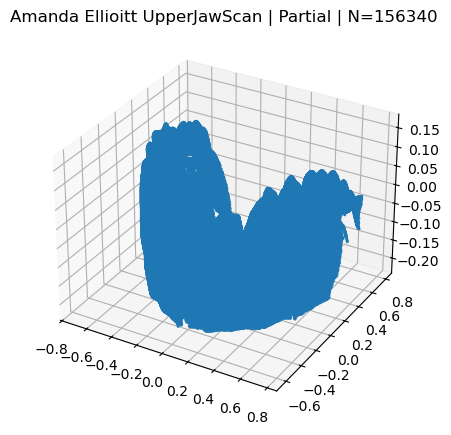

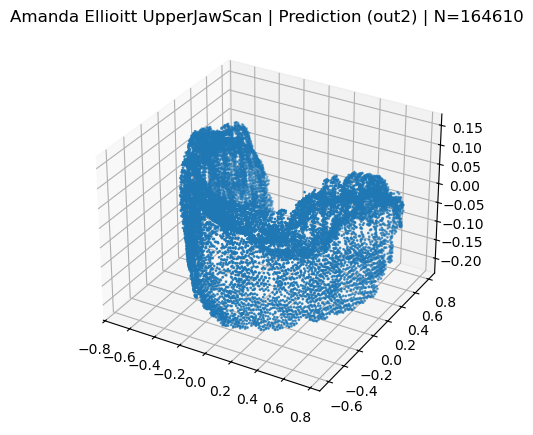

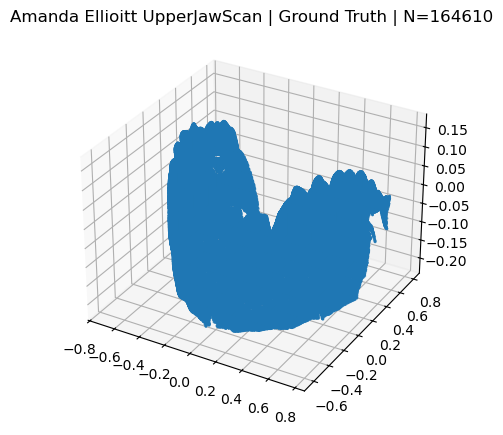

In [38]:
from __future__ import annotations

import sys
import yaml
import importlib
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from munch import Munch

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dataset_exact import PairPointCloudDataset

def plot_pc(pts, title):
    pts = np.asarray(pts, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 3:
        raise ValueError(f"{title}: expected (N,3), got {pts.shape}")

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1)
    ax.set_title(f"{title} | N={pts.shape[0]}")
    plt.show()

cfg_path = Path(REPO_ROOT) / "cfgs" / CFG.config_name
args = Munch.fromDict(yaml.safe_load(cfg_path.read_text()))

ds = PairPointCloudDataset(
    root=args.data_root,
    split=args.test_split,
    normalize=bool(args.normalize_pair),
    augment_train=False,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_module = importlib.import_module(f"models.{args.model_name}")
net = model_module.Model(args).to(device).eval()

ckpt = torch.load(args.load_model, map_location=device)
state = ckpt["net_state_dict"]
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
net.load_state_dict(state, strict=True)

@torch.no_grad()
def run_one(idx=0):
    label, partial, gt, stem = ds[idx]

    partial_t = partial.float().to(device)
    gt_t = gt.float().to(device)

    x = partial_t.unsqueeze(0).transpose(2, 1).contiguous()
    gt_b = gt_t.unsqueeze(0).contiguous()

    result = net(x, gt_b, is_training=False)
    pred = result["out2"][0].detach().cpu().numpy()

    print("Case:", stem)
    print("Partial shape   :", tuple(partial.shape))
    print("Prediction shape:", tuple(pred.shape))
    print("GT shape        :", tuple(gt.shape))

    plot_pc(partial.cpu().numpy(), f"{stem} | Partial")
    plot_pc(pred, f"{stem} | Prediction (out2)")
    plot_pc(gt.cpu().numpy(), f"{stem} | Ground Truth")

run_one(idx=0)   # change index as needed

In [39]:
from __future__ import annotations

import os
import sys
import yaml
import importlib
from pathlib import Path

import numpy as np
import torch

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from munch import Munch

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dataset_exact import PairPointCloudDataset

IDX_START = 0
IDX_END = None
EVERY_N = 1
DPI = 140
SKIP_IF_EXISTS = True

def _set_equal_axes(ax, pts_all: np.ndarray):
    mins = pts_all.min(axis=0)
    maxs = pts_all.max(axis=0)
    center = (mins + maxs) / 2.0
    radius = float(np.max(maxs - mins) / 2.0) + 1e-6
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

def _scatter3(ax, pts: np.ndarray, title: str):
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1)
    ax.set_title(f"{title} | N={pts.shape[0]}")

cfg_path = Path(REPO_ROOT) / "cfgs" / CFG.config_name
args = Munch.fromDict(yaml.safe_load(cfg_path.read_text()))

ds = PairPointCloudDataset(
    root=args.data_root,
    split=args.test_split,
    normalize=bool(args.normalize_pair),
    augment_train=False,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_module = importlib.import_module(f"models.{args.model_name}")
net = model_module.Model(args).to(device).eval()

ckpt_path = Path(str(args.load_model)).expanduser().resolve()
ckpt = torch.load(str(ckpt_path), map_location=device)
state = ckpt["net_state_dict"]
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
net.load_state_dict(state, strict=True)

ckpt_dir = ckpt_path.parent
pred_all_dir = ckpt_dir / "all"
vis_dir = ckpt_dir / f"vis_triplets_exact_{args.test_split}"
vis_dir.mkdir(parents=True, exist_ok=True)

print("Prediction folder:", pred_all_dir)
print("Triplet PNG folder:", vis_dir)

def _read_pred_file(path: Path) -> np.ndarray:
    if path.suffix.lower() == ".npy":
        return np.asarray(np.load(path), dtype=np.float32)
    elif path.suffix.lower() == ".ply":
        import open3d as o3d
        pcd = o3d.io.read_point_cloud(str(path))
        return np.asarray(pcd.points, dtype=np.float32)
    else:
        raise ValueError(f"Unsupported prediction file: {path}")

@torch.no_grad()
def get_pred_for_item(item):
    label, partial, gt, stem = item

    saved_npy = pred_all_dir / f"{stem}.npy"
    saved_ply = pred_all_dir / f"{stem}.ply"

    if saved_npy.exists():
        pred = _read_pred_file(saved_npy)
        return stem, partial, gt, pred, saved_npy
    if saved_ply.exists():
        pred = _read_pred_file(saved_ply)
        return stem, partial, gt, pred, saved_ply

    partial_t = partial.float().to(device)
    gt_t = gt.float().to(device)
    x = partial_t.unsqueeze(0).transpose(2, 1).contiguous()
    gt_b = gt_t.unsqueeze(0).contiguous()
    out = net(x, gt_b, is_training=False)
    pred = out["out2"][0].detach().cpu().numpy()
    return stem, partial, gt, pred, None

end = len(ds) if IDX_END is None else min(IDX_END, len(ds))
saved_count = 0

for idx in range(IDX_START, end, EVERY_N):
    item = ds[idx]
    stem, partial, gt, pred, pred_path = get_pred_for_item(item)

    out_png = vis_dir / f"idx{idx:04d}_{stem}.png"
    if SKIP_IF_EXISTS and out_png.exists():
        saved_count += 1
        continue

    partial_np = np.asarray(partial, dtype=np.float32)
    gt_np = np.asarray(gt, dtype=np.float32)
    pred_np = np.asarray(pred, dtype=np.float32)

    partial_v = partial_np
    pred_v = pred_np
    gt_v = gt_np

    pts_all = np.vstack([partial_v, pred_v, gt_v])

    fig = plt.figure(figsize=(15, 5), dpi=DPI)

    ax1 = fig.add_subplot(1, 3, 1, projection="3d")
    _scatter3(ax1, partial_v, "Partial")
    _set_equal_axes(ax1, pts_all)

    ax2 = fig.add_subplot(1, 3, 2, projection="3d")
    _scatter3(ax2, pred_v, "Prediction")
    _set_equal_axes(ax2, pts_all)

    ax3 = fig.add_subplot(1, 3, 3, projection="3d")
    _scatter3(ax3, gt_v, "Ground Truth")
    _set_equal_axes(ax3, pts_all)

    title = (
        f"Exact | idx={idx} | case={stem} | "
        f"N_partial={partial_v.shape[0]} | N_pred={pred_v.shape[0]} | N_gt={gt_v.shape[0]}"
    )
    if pred_path is not None:
        title += f" | pred_file={pred_path.name}"
    else:
        title += " | pred=ON-THE-FLY"

    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)

    saved_count += 1
    if saved_count % 25 == 0:
        print(f"Saved {saved_count} triplets -> {vis_dir}")

print(f"✅ Done. Saved {saved_count} triplet images to: {vis_dir}")

/tmp/ipykernel_3249796/2472908074.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(ckpt_path), map_location=device)


Prediction folder: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/all
Triplet PNG folder: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/vis_triplets_exact_test
✅ Done. Saved 5 triplet images to: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/vis_triplets_exact_test


In [40]:
from __future__ import annotations

import sys
import yaml
import importlib
from pathlib import Path

import numpy as np
import torch
from munch import munchify

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dataset_exact import PairPointCloudDataset

repo_root = Path(REPO_ROOT)
cfg_path = repo_root / "cfgs" / CFG.config_name
args = munchify(yaml.safe_load(cfg_path.read_text()))

ckpt_path = Path(str(args.load_model)).expanduser().resolve()
log_dir = ckpt_path.parent
eval_split = args.test_split

print(f"Detected dataset = {args.dataset} | eval_split = {eval_split}")
print(f"Checkpoint: {ckpt_path}")

ds = PairPointCloudDataset(
    root=args.data_root,
    split=eval_split,
    normalize=bool(args.normalize_pair),
    augment_train=False,
)

loader = torch.utils.data.DataLoader(
    ds,
    batch_size=int(getattr(args, "batch_size", 1)),
    shuffle=False,
    num_workers=1,
    drop_last=False,
    pin_memory=True,
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_module = importlib.import_module(f"models.{args.model_name}")
net = model_module.Model(args).to(device).eval()

ckpt = torch.load(str(ckpt_path), map_location=device)
state = ckpt["net_state_dict"]
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
net.load_state_dict(state, strict=True)

metrics = ["cd_p", "cd_t", "cd_t_coarse", "cd_p_coarse"]
sum_all = {m: 0.0 for m in metrics}
count_all = 0
case_rows = []

print("Evaluating ...")
with torch.no_grad():
    for i, batch in enumerate(loader):
        label, partial_cpu, gt_cpu, names = batch

        bs = partial_cpu.shape[0]
        partial = partial_cpu.float().to(device, non_blocking=True)
        gt = gt_cpu.float().to(device, non_blocking=True)

        x = partial.transpose(2, 1).contiguous()
        out = net(x, gt, is_training=False)

        for m in metrics:
            v = out[m].detach()
            sum_all[m] += float(v.sum().item())
        count_all += bs

        for j in range(bs):
            row = {"case": str(names[j])}
            for m in metrics:
                row[m] = float(out[m][j].item())
            case_rows.append(row)

        if i % max(1, int(getattr(args, "step_interval_to_print", 10))) == 0:
            print(f"  batch {i}/{len(loader)}")

overall = {m: (sum_all[m] / max(1, count_all)) for m in metrics}

print("\n=== Overview results (raw) ===")
print(" ".join([f"{m}: {overall[m]:.6f}" for m in metrics]))

out_txt = log_dir / f"quant_eval_exact_{eval_split}.txt"
with out_txt.open("w", encoding="utf-8") as f:
    f.write(f"dataset={args.dataset} split={eval_split}\n")
    f.write(f"ckpt={ckpt_path}\n\n")
    f.write("=== Overview results (raw) ===\n")
    f.write(" ".join([f"{m}: {overall[m]:.6f}" for m in metrics]) + "\n\n")
    f.write("=== Loss per case (raw) ===\n")
    for row in case_rows:
        line = f"case name: {row['case']}"
        for m in metrics:
            line += f" {m}: {row[m]:.6f}"
        f.write(line + "\n")

print(f"\nSaved results -> {out_txt}")

Detected dataset = dental_exact | eval_split = test
Checkpoint: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/best_cd_p_network.pth


/tmp/ipykernel_3249796/3445772717.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(ckpt_path), map_location=device)


Evaluating ...
  batch 0/5

=== Overview results (raw) ===
cd_p: 0.008489 cd_t: 0.000220 cd_t_coarse: 0.005707 cd_p_coarse: 0.049372

Saved results -> /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/quant_eval_exact_test.txt


In [41]:
from __future__ import annotations

import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path(REPO_ROOT).resolve()
search_roots = [repo_root, repo_root / "log"]

quant_files = []
for r in search_roots:
    if r.exists():
        quant_files += list(r.rglob("quant_eval_exact_*.txt"))

print("Repo root:", repo_root)
print("Found quant files:", len(quant_files))
for p in quant_files:
    print(" -", p)

if not quant_files:
    raise FileNotFoundError("No quant_eval_exact_*.txt found. Run the quantitative evaluation cell first.")

def parse_quant_file(fp: Path) -> dict:
    lines = fp.read_text(encoding="utf-8", errors="ignore").splitlines()

    dataset = None
    split = None
    ckpt = None
    overview = {}
    case_rows = []

    in_overview = False
    in_case = False

    for ln in lines:
        ln = ln.strip()

        if ln.startswith("dataset="):
            m = re.match(r"dataset=(\S+)\s+split=(\S+)", ln)
            if m:
                dataset, split = m.group(1).lower(), m.group(2).lower()

        if ln.startswith("ckpt="):
            ckpt = ln.split("=", 1)[1].strip()

        if "=== Overview results" in ln:
            in_overview, in_case = True, False
            continue

        if "=== Loss per case" in ln:
            in_overview, in_case = False, True
            continue

        if in_overview:
            tokens = ln.split()
            for i in range(0, len(tokens) - 1, 2):
                k = tokens[i].rstrip(":")
                v = tokens[i + 1]
                if k in {"cd_p", "cd_t", "cd_t_coarse", "cd_p_coarse"}:
                    try:
                        overview[k] = float(v)
                    except Exception:
                        pass

        if in_case:
            m = re.match(
                r"^case name:\s*(.+?)\s+cd_p:\s*([0-9.eE+-]+)\s+cd_t:\s*([0-9.eE+-]+)\s+cd_t_coarse:\s*([0-9.eE+-]+)\s+cd_p_coarse:\s*([0-9.eE+-]+)$",
                ln
            )
            if m:
                case_rows.append({
                    "case": m.group(1),
                    "cd_p": float(m.group(2)),
                    "cd_t": float(m.group(3)),
                    "cd_t_coarse": float(m.group(4)),
                    "cd_p_coarse": float(m.group(5)),
                })

    return {
        "file": str(fp),
        "dataset": dataset,
        "split": split,
        "ckpt": ckpt,
        "overview": overview,
        "per_case": pd.DataFrame(case_rows),
    }

parsed = [parse_quant_file(p) for p in quant_files]
parsed.sort(key=lambda d: Path(d["file"]).stat().st_mtime, reverse=True)
use = parsed[:1]   # latest exact run

d = use[0]
print("\nUsing quant file:", d["file"])

overview_df = pd.DataFrame([{
    "dataset": d["dataset"],
    "split": d["split"],
    "ckpt": d["ckpt"],
    "cd_p": d["overview"].get("cd_p", float("nan")),
    "cd_t": d["overview"].get("cd_t", float("nan")),
    "cd_t_coarse": d["overview"].get("cd_t_coarse", float("nan")),
    "cd_p_coarse": d["overview"].get("cd_p_coarse", float("nan")),
}]).set_index("dataset")

display(overview_df)

case_df = d["per_case"].copy()
if not case_df.empty:
    display(case_df.head())
else:
    print("No per-case rows found.")

report_dir = repo_root / "log" / "exact_quant_report"
report_dir.mkdir(parents=True, exist_ok=True)
print("\nReport folder:", report_dir)

overview_csv = report_dir / "overview_exact.csv"
overview_df.to_csv(overview_csv)
print("Saved:", overview_csv)

if not case_df.empty:
    case_csv = report_dir / "per_case_exact.csv"
    case_df.to_csv(case_csv, index=False)
    print("Saved:", case_csv)

fig1 = plt.figure(figsize=(8, 4))
ax = fig1.add_subplot(111)
metrics = ["cd_p", "cd_t", "cd_t_coarse", "cd_p_coarse"]
vals = [overview_df.iloc[0][m] for m in metrics]
ax.bar(metrics, vals)
ax.set_xticklabels(metrics, rotation=20, ha="right")
ax.set_title("Exact dataset overview metrics (raw)")
fig1.tight_layout()

fig1_path = report_dir / "fig_overview_exact.png"
fig1.savefig(fig1_path, dpi=160)
plt.show()
print("Saved:", fig1_path)

if not case_df.empty:
    fig2 = plt.figure(figsize=(12, 4))
    ax = fig2.add_subplot(111)
    ax.bar(case_df["case"], case_df["cd_p"])
    ax.set_title("Exact dataset: cd_p by case")
    ax.set_ylabel("cd_p")
    ax.set_xticklabels(case_df["case"], rotation=45, ha="right")
    fig2.tight_layout()

    fig2_path = report_dir / "fig_cd_p_by_case.png"
    fig2.savefig(fig2_path, dpi=160)
    plt.show()
    print("Saved:", fig2_path)

print("\n✅ Exact quantitative report complete.")

Repo root: /home/n0etem01/PointAttN (2024)/PointAttN-main
Found quant files: 2
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/quant_eval_exact_test.txt
 - /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/quant_eval_exact_test.txt

Using quant file: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/PointAttN_exact_cd_exact_dental_exact/quant_eval_exact_test.txt


,split,ckpt,cd_p,cd_t,cd_t_coarse,cd_p_coarse
dataset,,,,,,
dental_exact,test,/home/n0etem01/PointAttN (2024)/PointAttN-main...,0.008489,0.00022,0.005707,0.049372


,case,cd_p,cd_t,cd_t_coarse,cd_p_coarse
0,Amanda Ellioitt UpperJawScan,0.010322,0.000348,0.007945,0.058409
1,David Donatelli UpperJawScan,0.007535,0.000151,0.004465,0.044189
2,Kim Petros UpperJawScan,0.007739,0.000192,0.003700,0.039956
3,jolene zirnheld UpperJawScan,0.008922,0.000235,0.006189,0.051890
4,tarin williams 37-44 UpperJawScan,0.007925,0.000173,0.006238,0.052416



Report folder: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/exact_quant_report
Saved: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/exact_quant_report/overview_exact.csv
Saved: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/exact_quant_report/per_case_exact.csv
Saved: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/exact_quant_report/fig_overview_exact.png
Saved: /home/n0etem01/PointAttN (2024)/PointAttN-main/log/exact_quant_report/fig_cd_p_by_case.png

✅ Exact quantitative report complete.


/tmp/ipykernel_3249796/1546621452.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metrics, rotation=20, ha="right")
/tmp/ipykernel_3249796/1546621452.py:139: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_3249796/1546621452.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(case_df["case"], rotation=45, ha="right")
/tmp/ipykernel_3249796/1546621452.py:153: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [42]:
import numpy as np
from pathlib import Path
import yaml

cfg_path = Path(REPO_ROOT) / "cfgs" / CFG.config_name
args = yaml.safe_load(cfg_path.read_text())

pred_path = Path(args["load_model"]).resolve().parent / "all" / "Amanda Ellioitt UpperJawScan.npy"
gt_path = Path(args["data_root"]) / args["test_split"] / "gt" / "Amanda Ellioitt UpperJawScan.npy"

pred = np.load(pred_path)
gt = np.load(gt_path)

print("pred shape:", pred.shape)
print("gt shape  :", gt.shape)

print("pred min:", pred.min(axis=0), "pred max:", pred.max(axis=0))
print("gt   min:", gt.min(axis=0),   "gt   max:", gt.max(axis=0))

pred shape: (164610, 3)
gt shape  : (164610, 3)
pred min: [-0.7066982  -0.6140641  -0.21376027] pred max: [0.7623466  0.78793335 0.15195526]
gt   min: [-0.38079253 -0.29964358 -0.10859296] gt   max: [0.35375232 0.40300933 0.07775362]
